# **Деревья решений**

## **Подготовка для работы в Google Colab или Kaggle**

#### Код для подключения Google Drive в Colab

#### Код для получения пути к файлам в Kaggle

#### Код для установки библиотек

## **Важная информация**

**Для правильного воспроизведения результатов** решения задач:

* Рекомендуется придерживаться имеющего в заданиях кода в исходной последовательности. Для этого при решении задач **восстановите недостающие фрагменты кода, которые отмечены символом** `...` (Ellipsis).

* Если класс, функция или метод предусматривает параметр random_state, всегда указывайте **random_state=RANDOM_STATE**.

* Для всех параметров (кроме random_state) класса, функции или метода **используйте значения по умолчанию, если иное не указано в задании**.

**Если скорость обучения слишком низкая**, рекомендуется следующее:

* В модели или/и GridSearchCV поменяйте значение параметра n_jobs, который отвечает за параллелизм вычислений.

* Воспользуйтесь вычислительными ресурсами Google Colab или Kaggle.

***Использовать GPU не рекомендуется, поскольку результаты обучения некоторых моделей могут отличаться на CPU и GPU.***

После выполнения каждого задания **ответьте на вопросы в тесте.**

**ВНИМАНИЕ:** **После каждого нового запуска ноутбука** перед тем, как приступить к выполнению заданий, проверьте настройку виртуального окружения, выполнив код в ячейке ниже.

In [1]:
# Код для проверки настройки виртуального окружения

import sys
from importlib.metadata import version

required = {
    'python': '3.12.x',
    'scipy': '1.16.3',
    'numpy': '2.0.2',
    'pandas': '2.2.2',
    'scikit-learn': '1.6.1',
    'matplotlib': '3.10.0',
    'graphviz': '0.21'
}

print(f'{"Компонент":<15} | {"Требуется":<12} | {"Установлено":<12} | {"Соответствие"}')
print('-' * 62)

environment_ok = True
for lib, req_ver in required.items():
    try:
        if lib=='python':
            inst_ver = sys.version.split()[0]
            status = '✓' if sys.version_info.major == 3 and sys.version_info.minor == 12 else f'x (требуется {req_ver})'
        else:
            inst_ver = version(lib)
            if inst_ver == req_ver:
                status = '✓'
            else:
                environment_ok = False
                status = f'x (требуется {req_ver})'
    except:
        environment_ok = False
        inst_ver = '-'
        status = 'x (не установлена)'
    print(f'{lib:<15} | {req_ver:<12} | {inst_ver:<12} | {status:<12}')

print('\nРезультат проверки: ', 
      '✓\nВсе версии соответствуют требованиям' 
      if environment_ok else 
      'x\nВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!\n'
      'Для решения проблемы обратитесь к инструкции по настройке виртуального окружения')

Компонент       | Требуется    | Установлено  | Соответствие
--------------------------------------------------------------
python          | 3.12.x       | 3.11.7       | x (требуется 3.12.x)
scipy           | 1.16.3       | 1.16.3       | ✓           
numpy           | 2.0.2        | 1.26.4       | x (требуется 2.0.2)
pandas          | 2.2.2        | 2.2.2        | ✓           
scikit-learn    | 1.6.1        | 1.6.0        | x (требуется 1.6.1)
matplotlib      | 3.10.0       | 3.10.8       | x (требуется 3.10.0)
graphviz        | 0.21         | 0.21         | ✓           

Результат проверки:  x
ВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!
Для решения проблемы обратитесь к инструкции по настройке виртуального окружения


## **Импорт библиотек и вспомогательные функции**

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import graphviz

from sklearn import tree
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import classification_report, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

In [3]:
RANDOM_STATE = 42

In [4]:
def metrics_report(y_true, y_pred):
    """
    Выводит отчёт с основными метриками качества регрессии.
    Округляет до 4-х знаков после запятой и выводит значения R2 (коэффициент детерминации), RMSE (среднеквадратичная ошибка) и 
    MAPE (средняя абсолютная процентная ошибка) для оценки качества предсказаний.

    Аргументы:
        y_true (numpy.ndarray): Истинные значения целевой переменной.
        y_pred (numpy.ndarray): Предсказанные значения целевой переменной.
    """
    print(f'R2 score: {r2_score(y_true, y_pred):.4f}')
    print(f'RMSE: {mean_squared_error(y_true, y_pred)**0.5:.4f}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred):.4f}')

## **Практическая часть**

### **Определения**

* **Дерево решений** — это модель, построенная на основе решающих правил вида «если, то», упорядоченных в древовидную иерархическую структуру.

* **Узел** (node) — это элемент дерева, который может быть либо внутренним (с условием проверки признака), либо листом (с конечным решением). 

* **Внутренний узел** — это элемент дерева, который выполняет проверку значений признаков и направляет объекты к подузлам в зависимости от результата проверки.

* **Лист** (leaf) — это терминальный узел дерева, принимающий решение, то есть присваивающий объекту конечную метку класса (в задачах классификации) или значение целевой переменной (в задачах регрессии).

* **Глубина дерева** — это максимальное число ребер (уровней), которые необходимо пройти, начиная от корневого узла до самого глубокого листового узла.

### **Деревья решений в задаче классификации**

В рамках задачи классификации дерево решений рекурсивно разбивает данные на подмножества, стремясь максимизировать "чистоту" узлов, то есть стремясь к ситуации, когда в каждом узле дерева преобладают объекты одного класса.

Один из основных способов оценки качества разбиения — **индекс (критерий) Джини (Gini impurity)**, измеряющий вероятность ошибки, если случайно классифицировать объект в узле согласно распределению классов. Чем ниже значение индекса Джини, тем чище множество (лучше разделение).

Формула индекса Джини:

$$\text{G}=1-\sum_{i=1}^{k}{p^{2}_{i}}$$

где $k$ — количество классов, $p_{i}$ — доля объектов класса $i$ в узле.

Еще одним критерием для оценки разбиения является энтропия:

$$\text{H}=-\sum_{i=1}^{k}{p_{i}\log p_{i}}$$

Энтропия измеряет степень неопределенности в распределении классов. Энтропия равна нулю, если узел "чистый" (все объекты в узле относятся к одному классу), и достигает максимума, если классы распределены равномерно.

Оба критерия имеют схожие свойства и часто приводят к похожим результатам, но энтропия сильнее штрафует не однородные узлы. На практике выбор между критериями зависит от конкретной задачи и данных.

### ***Задание 1***

Сгенерируйте набор данных с двумя классами и двумя признаками с помощью [make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) (см. код).

Реализуйте два простейших дерева решений, дополнив функции one_rule_tree_predict и two_rules_tree_predict:

* Дерево с одним узлом (функция one_rule_tree_predict):

    * если $x_1 \le -0.5$, то 0

    * иначе: 1

* Дерево с двумя узлами (функция two_rules_tree_predict):

    * если $x_1 \le -0.5$, то 0

    * иначе:
    
        * если $x_2 \le 0$, то 1
        
        * иначе: 0

Дополните класс CustomDecisionTreeClassifier, добавив недостающий код там, где это необходимо.

Обучите два дерева решений **c максимальной глубиной 3** на всем наборе данных:

* `tree_custom` — дерево CustomDecisionTreeClassifier.

* `tree_sk` — дерево DecisionTreeClassifier из библиотеки sklearn.

Для каждого из деревьев решений, включая простейшие деревья в виде функций (one_rule_tree_predict, two_rules_tree_predict, `tree_custom`, `tree_sk`), постройте отчёт по метрикам классификации.

In [5]:
def display_decision_boundary(classifier, features, labels):
    """
    Визуализирует границу решений классификатора на двумерных данных.

    Аргументы:
        classifier (callable): Функция или метод модели, принимающий таблицу с признаками и возвращающий предсказанные классы.
        features (pandas.DataFrame): Двумерная таблица с признаками (только два признака), по которым строится визуализация.
        labels (numpy.ndarray): Массив меток классов.
    """
    x1_min, x1_max = features.iloc[:, 0].min() - 1, features.iloc[:, 0].max() + 1
    x2_min, x2_max = features.iloc[:, 1].min() - 1, features.iloc[:, 1].max() + 1
    x1x1, x2x2 = np.meshgrid(np.arange(x1_min, x1_max, 0.01), np.arange(x2_min, x2_max, 0.01))
    decision = classifier(pd.DataFrame(np.c_[x1x1.ravel(), x2x2.ravel()], columns=features.columns)).reshape(x1x1.shape)
    plt.contourf(x1x1, x2x2, decision, alpha=0.5)
    plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, edgecolors='k')
    plt.show()

In [6]:
# Сгенерируйте набор данных с двумя классами и двумя признаками с помощью make_moons

features, labels = datasets.make_moons(n_samples=200, noise=0.15, random_state=RANDOM_STATE)
features = pd.DataFrame(features)
features.columns = ['x1', 'x2']

In [7]:
# В features два признака: x1 и x2

features

,x1,x2
0,-1.078161,0.063368
1,0.939809,0.457119
2,0.695151,0.642107
3,1.150173,-0.347871
4,0.249173,-0.068544
...,...,...
195,-0.039215,0.248731
196,0.778639,0.348020
197,-1.350844,0.323007
198,1.863808,-0.105644


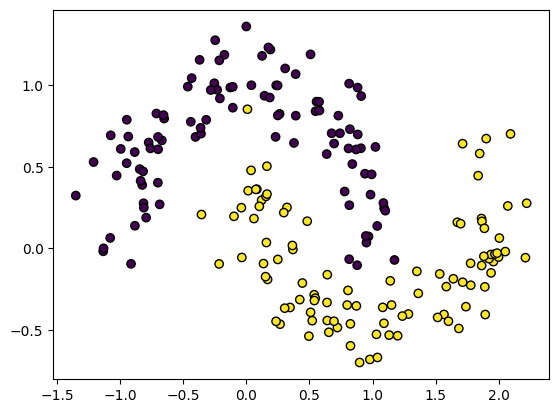

In [8]:
# Визуализируйте датасет

plt.scatter(features['x1'], features['x2'], c=labels, edgecolors='k')
plt.show()

In [9]:
# Дополните функцию one_rule_tree_predict

def one_rule_tree_predict(features):
    """
    Реализация предсказаний простейшего дерева решений с одним узлом:
        если x1 <= -0.5, то 0
        иначе: 1

    Аргументы:
        features (pandas.DataFrame): Таблица с входными признаками.

    Возвращает:
        numpy.ndarray: Массив предсказанных меток классов.
    """
    # Извлекаем столбец x1 как массив numpy для удобства
    x1_values = features['x1'].values
    
    # Создаем массив для предсказаний, изначально заполняем его единицами (для ветки "иначе")
    predictions = np.ones(len(features), dtype=int)
    
    # Применяем правило: если x1 <= -0.5, то присваиваем 0
    predictions[x1_values <= -0.5] = 0
    
    return predictions

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def classification_metrics_report(y_true, y_pred):
    """
    Выводит отчёт с основными метриками качества классификации.
    Округляет до 4-х знаков после запятой и выводит значения accuracy, precision, recall и f1-score.

    Аргументы:
        y_true (numpy.ndarray): Истинные значения целевой переменной.
        y_pred (numpy.ndarray): Предсказанные значения целевой переменной.
    """
    print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall: {recall_score(y_true, y_pred):.4f}')
    print(f'F1-score: {f1_score(y_true, y_pred):.4f}')

In [11]:
# Постройте отчет по метрикам классификации для one_rule_tree_predict на всем наборе данных

# Получаем предсказания для one_rule_tree_predict
predictions_one_rule = one_rule_tree_predict(features)

# Выводим отчет по метрикам классификации
print("Метрики для one_rule_tree_predict:")
classification_metrics_report(labels, predictions_one_rule)

Метрики для one_rule_tree_predict:
Accuracy: 0.6550
Precision: 0.5917
Recall: 1.0000
F1-score: 0.7435


In [12]:
from sklearn.metrics import classification_report

# Получаем предсказания для всего набора данных
predictions_one_rule = one_rule_tree_predict(features)

# Выводим отчет по метрикам классификации
print("Отчет по метрикам для one_rule_tree_predict:")
print(classification_report(labels, predictions_one_rule, target_names=['Класс 0', 'Класс 1']))

Отчет по метрикам для one_rule_tree_predict:
              precision    recall  f1-score   support

     Класс 0       1.00      0.31      0.47       100
     Класс 1       0.59      1.00      0.74       100

    accuracy                           0.66       200
   macro avg       0.80      0.66      0.61       200
weighted avg       0.80      0.66      0.61       200



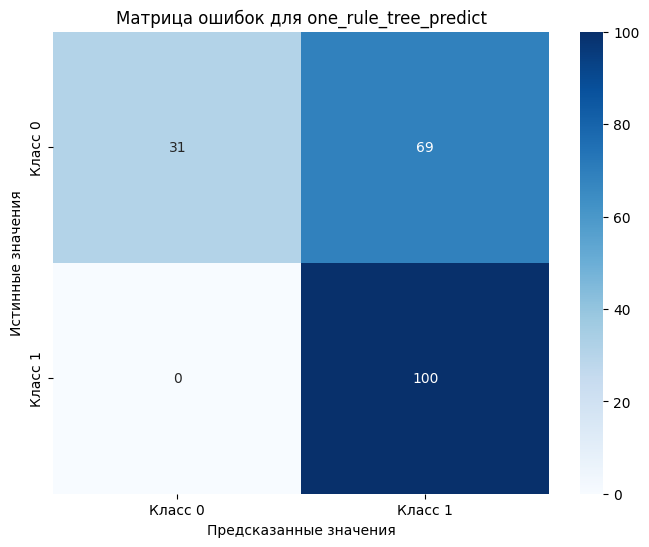

In [13]:
# Для наглядности также построим матрицу ошибок
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(labels, predictions_one_rule)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Класс 0', 'Класс 1'], 
            yticklabels=['Класс 0', 'Класс 1'])
plt.title('Матрица ошибок для one_rule_tree_predict')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

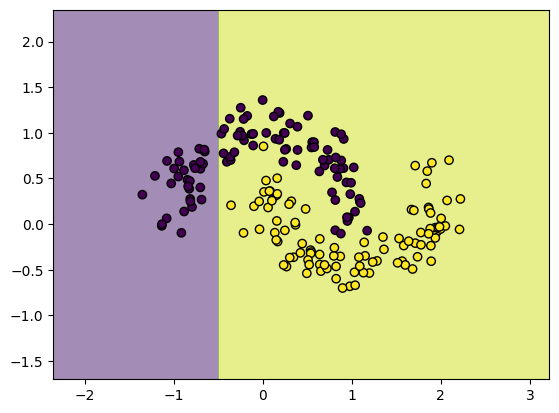

In [14]:
# Визуализируйте границу решений классификатора one_rule_tree_predict на всем наборе данных

display_decision_boundary(one_rule_tree_predict, features, labels)

In [15]:
# Дополните функцию two_rules_tree_predict

def two_rules_tree_predict(features):
    """
    Реализация предсказаний простейшего дерева решений с двумя узлами:
        если x1 <= -0.5, то 0
        иначе:
            если x2 <= 0, то 1
            иначе: 0

    Аргументы:
        features (pandas.DataFrame): Таблица с входными признаками.

    Возвращает:
        numpy.ndarray: Массив предсказанных меток классов.   


    Векторизованная версия для предсказаний с двумя узлами.
    """
    x1_values = features['x1'].values
    x2_values = features['x2'].values
    
    # Создаем массив предсказаний, изначально заполняем его 0
    predictions = np.zeros(len(features), dtype=int)
    
    # Находим индексы, где x1 > -0.5 (ветка "иначе")
    mask_x1_greater = x1_values > -0.5
    
    # Среди этих индексов применяем второе правило
    # Если x2 <= 0, то присваиваем 1
    predictions[mask_x1_greater & (x2_values <= 0)] = 1
    # Если x2 > 0, оставляем 0 (уже установлено по умолчанию)
    
    return predictions

ОТЧЕТ ПО МЕТРИКАМ ДЛЯ two_rules_tree_predict

1. Основные метрики классификации:
Accuracy: 0.8250
Precision: 0.9577
Recall: 0.6800
F1-score: 0.7953

2. Детальный отчет по классам:
              precision    recall  f1-score   support

     Класс 0     0.7519    0.9700    0.8472       100
     Класс 1     0.9577    0.6800    0.7953       100

    accuracy                         0.8250       200
   macro avg     0.8548    0.8250    0.8212       200
weighted avg     0.8548    0.8250    0.8212       200


3. Матрица ошибок:
             Предсказано
           0    1
Истинно 0   97    3
        1   32   68


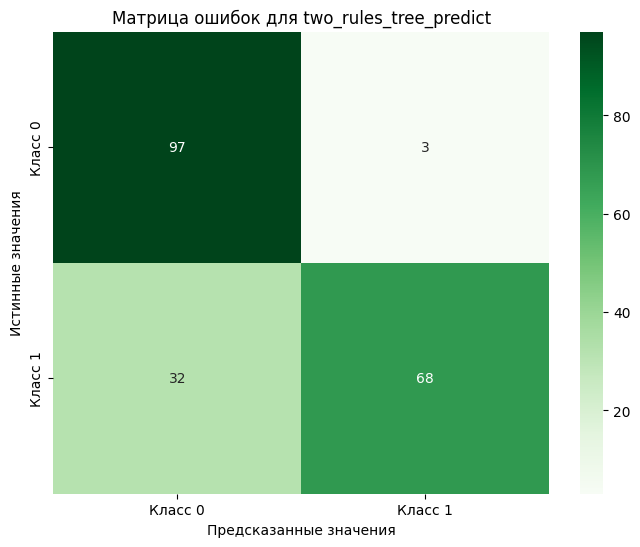

In [16]:
# Постройте отчет по метрикам классификации для two_rules_tree_predict на всем наборе данных

# Получаем предсказания для two_rules_tree_predict
predictions_two_rules = two_rules_tree_predict(features)

# Выводим отчет по метрикам классификации
print("="*50)
print("ОТЧЕТ ПО МЕТРИКАМ ДЛЯ two_rules_tree_predict")
print("="*50)
print("\n1. Основные метрики классификации:")
classification_metrics_report(labels, predictions_two_rules)

# Дополнительный детальный отчет с разбивкой по классам
from sklearn.metrics import classification_report

print("\n2. Детальный отчет по классам:")
print(classification_report(labels, predictions_two_rules, 
                          target_names=['Класс 0', 'Класс 1'],
                          digits=4))

# Матрица ошибок
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\n3. Матрица ошибок:")
cm = confusion_matrix(labels, predictions_two_rules)
print("             Предсказано")
print("           0    1")
print(f"Истинно 0  {cm[0,0]:3d}  {cm[0,1]:3d}")
print(f"        1  {cm[1,0]:3d}  {cm[1,1]:3d}")

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Класс 0', 'Класс 1'], 
            yticklabels=['Класс 0', 'Класс 1'])
plt.title('Матрица ошибок для two_rules_tree_predict')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

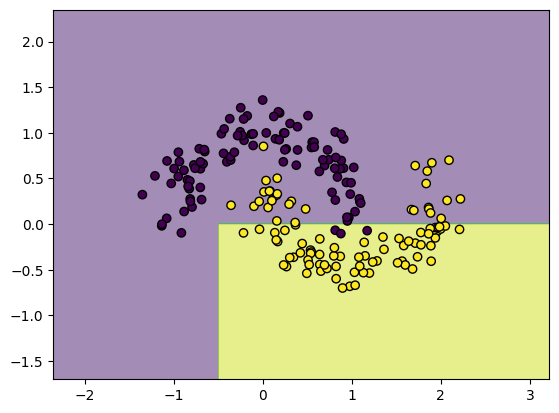

In [17]:
# Визуализируйте границу решений классификатора two_rules_tree_predict на всем наборе данных

display_decision_boundary(two_rules_tree_predict, features, labels)

Основываясь на метриках, проанализируем каждое утверждение:

1. **"Простейшее дерево с одним узлом (one_rule_tree_predict) идеально определяет все объекты класса 1."**
   - Смотрим recall для класса 1 в one_rule_tree_predict: **1.00**
   - Это означает, что действительно ВСЕ объекты класса 1 были определены правильно
   - **Утверждение ВЕРНО**

2. **"Метрика accuracy дерева с двумя правилами (two_rules_tree_predict) не значительно выше (разница не превышает 0.1), чем accuracy у дерева с одним правилом (one_rule_tree_predict)."**
   - Accuracy one_rule: 0.6550
   - Accuracy two_rules: 0.8250
   - Разница: 0.8250 - 0.6550 = **0.17**, что превышает 0.1
   - **Утверждение НЕВЕРНО**

3. **"Значение метрики accuracy дерева с двумя узлами (two_rules_tree_predict) больше 0.80."**
   - Accuracy two_rules = **0.8250**, что действительно больше 0.80
   - **Утверждение ВЕРНО**

4. **"У дерева с двумя правилами (two_rules_tree_predict) метрика precision для класса 0 выше, чем recall для того же класса."**
   - Для класса 0: precision = 0.7519, recall = 0.9700
   - 0.7519 < 0.9700, значит precision НЕ выше recall
   - **Утверждение НЕВЕРНО**

**Верные утверждения:**
- ✅ Простейшее дерево с одним узлом идеально определяет все объекты класса 1.
- ✅ Значение метрики accuracy дерева с двумя узлами больше 0.80.

In [18]:
import numpy as np
import pandas as pd
import graphviz

class CustomDecisionTreeClassifier():
    """
    Простой классификатор на основе дерева решений с критерием Джини в качестве критерия разделения.

    Аргументы:
        max_depth (int): Максимальная глубина дерева. По умолчанию — 3.

    Атрибуты:
        label (int): Метка класса, который наиболее часто встречается в узле.
        feature (str): Признак, используемый для разделения.
        size (int): Количество объектов в узле.
        threshold (float): Пороговое значение для разделения.
        left (CustomDecisionTreeClassifier): Левое поддерево (значение <= порог).
        right (CustomDecisionTreeClassifier): Правое поддерево (значение > порог).
        gini (float): Индекс Джини в узле.
    """
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.label = None
        self.feature = None
        self.size = None
        self.threshold = np.nan
        self.left = None
        self.right = None
        self.gini = 0

    def gini_impurity(self, y):
        """
        Вычисляет индекс Джини для массива меток классов.

        Аргументы:
            y (numpy.ndarray): Массив меток классов.

        Возвращает:
            float: Значение индекса Джини.
        """
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)

    def best_split(self, X, y):
        """
        Находит оптимальный признак и порог для разделения данных.

        Аргументы:
            X (pandas.DataFrame): Таблица с признаками.
            y (numpy.ndarray): Массив меток классов.

        Возвращает:
            tuple:
                str: Оптимальный признак для разделения.
                float: Оптимальное пороговое значение.
                float: Значение индекса Джини после оптимального разделения.
        """
        best_feature = None
        best_threshold = None
        best_gini = self.gini_impurity(y)
        N = X.shape[0]
        
        for feature in X.columns:
            values = np.sort(X[feature].unique())
            thresholds = [(values[i] + values[i+1]) / 2 for i in range(len(values)-1)]
            
            for threshold in thresholds:
                mask_left = X[feature] <= threshold
                mask_right = ~mask_left
                
                N_left = mask_left.sum()
                N_right = mask_right.sum()
                
                if N_left == 0 or N_right == 0:
                    continue
                
                gini_left = self.gini_impurity(y[mask_left])
                gini_right = self.gini_impurity(y[mask_right])
                
                weighted_gini = (N_left * gini_left + N_right * gini_right) / N
                
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold
                    
        return best_feature, best_threshold, best_gini

    def fit(self, X, y):
        """
        Обучает дерево решений, рекурсивно находя оптимальные разделения.

        Аргументы:
            X (pandas.DataFrame): Таблица с признаками.
            y (numpy.ndarray): Массив меток классов.

        Возвращает:
            CustomDecisionTreeClassifier: Обученное дерево решений.
        """
        self.size = len(y)
        classes, counts = np.unique(y, return_counts=True)
        self.label = classes[np.argmax(counts)]
        self.gini = self.gini_impurity(y)
        
        if self.max_depth == 0:
            return self
            
        self.feature, self.threshold, gini = self.best_split(X, y)
        
        if self.feature is None or gini >= self.gini:
            self.feature = None
            return self
            
        self.gini = gini
        
        mask_left = X[self.feature] <= self.threshold
        mask_right = ~mask_left
        
        self.left = CustomDecisionTreeClassifier(max_depth=self.max_depth - 1)
        self.right = CustomDecisionTreeClassifier(max_depth=self.max_depth - 1)
        
        self.left.fit(X[mask_left], y[mask_left])
        self.right.fit(X[mask_right], y[mask_right])
        
        return self

    def predict(self, X):
        """
        Предсказывает метки классов.

        Аргументы:
            X (pandas.DataFrame): Таблица с признаками.

        Возвращает:
            numpy.ndarray: Массив предсказанных меток классов.
        """
        if self.feature is None:
            return np.full(X.shape[0], self.label)
        
        mask_left = X[self.feature] <= self.threshold
        mask_right = ~mask_left
        
        y_pred = np.empty(X.shape[0])
        y_pred[mask_left] = self.left.predict(X[mask_left])
        y_pred[mask_right] = self.right.predict(X[mask_right])
        
        return y_pred

    def plot_node(self, dot, node_id=0):
        """
        Вспомогательный метод для визуализации дерева.

        Аргументы:
            dot (graphviz.Digraph): Объект Digraph библиотеки graphviz.
            node_id (int): Идентификатор текущего узла. По умолчанию — 0.

        Возвращает:
            int: Идентификатор узла.
        """
        if self.feature is None:
            label = f"gini = {self.gini:.3f}\nsamples = {self.size}\nlabel = {self.label}"
            dot.node(str(node_id), label=label, fillcolor="#8ccd96")
            return node_id
        label = f"{self.feature} <= {self.threshold:.3f}\ngini = {self.gini:.3f}\nsamples = {self.size}\nlabel = {self.label}"
        dot.node(str(node_id), label=label, fillcolor="#ffffff")
        left_id = self.left.plot_node(dot, node_id*2 + 1)
        dot.edge(str(node_id), str(left_id))
        right_id = self.right.plot_node(dot, node_id*2 + 2)
        dot.edge(str(node_id), str(right_id))
        return node_id

    def plot_tree(self, filled=True):
        """
        Генерирует визуализацию дерева решений.

        Аргументы:
            filled (bool): Закрашивать узлы. По умолчанию — True.

        Возвращает:
            graphviz.Digraph: Объект graphviz с визуализацией дерева.
        """
        dot = graphviz.Digraph()
        dot.attr('node', shape='box', style='filled' if filled else None)
        self.plot_node(dot)
        return dot
    
    def count_nodes(self):
        """
        Рассчитывает сложность дерева — совокупное количество узлов в дереве.

        Возвращает:
            int: Общее количество узлов.
        """
        if self.feature is None:
            return 1
        return 1 + self.left.count_nodes() + self.right.count_nodes()

In [19]:
# Обучите дерево tree_custom (CustomDecisionTreeClassifier)
# Максимальная глубина — 3

# Создаем экземпляр класса с max_depth=3
tree_custom = CustomDecisionTreeClassifier(max_depth=3)

# Обучаем модель на всем наборе данных
tree_custom.fit(features, labels)

# Получаем предсказания
predictions_custom = tree_custom.predict(features)

ОТЧЕТ ПО МЕТРИКАМ ДЛЯ CustomDecisionTreeClassifier (max_depth=3)

1. ОСНОВНЫЕ МЕТРИКИ:
----------------------------------------
Accuracy: 0.9200
Precision: 0.8818
Recall: 0.9700
F1-score: 0.9238

2. ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:
----------------------------------------
              precision    recall  f1-score   support

     Класс 0     0.9667    0.8700    0.9158       100
     Класс 1     0.8818    0.9700    0.9238       100

    accuracy                         0.9200       200
   macro avg     0.9242    0.9200    0.9198       200
weighted avg     0.9242    0.9200    0.9198       200


3. МАТРИЦА ОШИБОК:
----------------------------------------
             Предсказано
           0    1
Истинно 0   87   13
        1    3   97


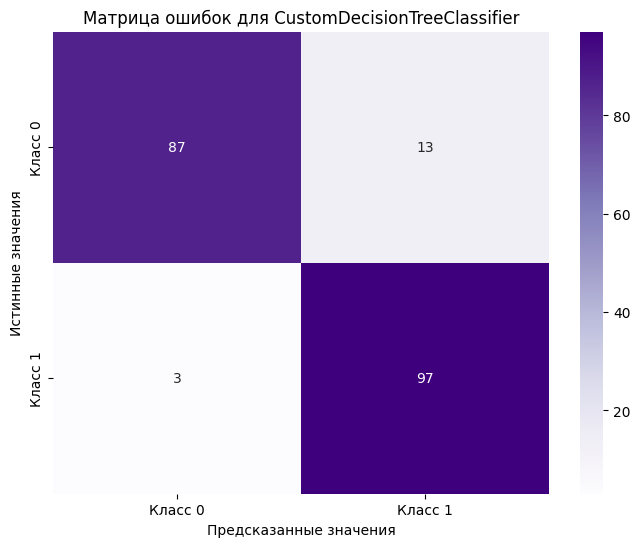

In [20]:
# Постройте отчет по метрикам классификации для tree_custom на всем наборе данных

# Выводим отчет по метрикам классификации
print("="*60)
print("ОТЧЕТ ПО МЕТРИКАМ ДЛЯ CustomDecisionTreeClassifier (max_depth=3)")
print("="*60)

# 1. Основные метрики через нашу функцию
print("\n1. ОСНОВНЫЕ МЕТРИКИ:")
print("-" * 40)
classification_metrics_report(labels, predictions_custom)

# 2. Детальный отчет по классам от sklearn
print("\n2. ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print("-" * 40)
print(classification_report(labels, predictions_custom, 
                          target_names=['Класс 0', 'Класс 1'],
                          digits=4))

# 3. Матрица ошибок
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\n3. МАТРИЦА ОШИБОК:")
print("-" * 40)
cm_custom = confusion_matrix(labels, predictions_custom)
print("             Предсказано")
print("           0    1")
print(f"Истинно 0  {cm_custom[0,0]:3d}  {cm_custom[0,1]:3d}")
print(f"        1  {cm_custom[1,0]:3d}  {cm_custom[1,1]:3d}")

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Класс 0', 'Класс 1'], 
            yticklabels=['Класс 0', 'Класс 1'])
plt.title('Матрица ошибок для CustomDecisionTreeClassifier')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

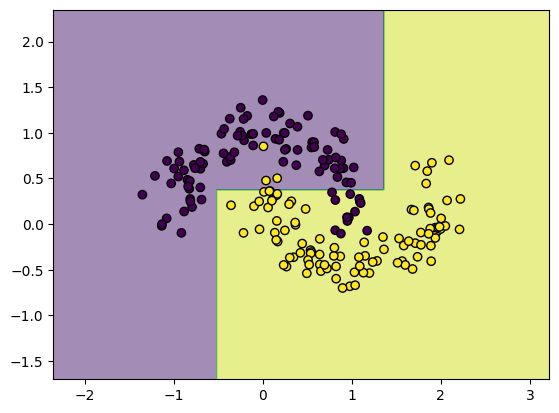

In [21]:
# Визуализируйте границу решений классификатора tree_custom на всем наборе данных

display_decision_boundary(tree_custom.predict, features, labels)

In [22]:
# Визуализируйте дерево tree_custom

# tree_custom.plot_tree()

In [23]:
# Визуализация дерева tree_custom (только текстовая версия, без graphviz)

print("="*60)
print("ВИЗУАЛИЗАЦИЯ ДЕРЕВА CustomDecisionTreeClassifier")
print("="*60)

# 1. Текстовое представление структуры дерева
print("\n1. СТРУКТУРА ДЕРЕВА (иерархическое представление):")
print("-" * 60)

def print_tree_structure(node, depth=0, prefix="Корень: "):
    """Рекурсивно выводит структуру дерева с отступами"""
    indent = "  " * depth
    
    if node.feature is None:
        print(f"{indent}{prefix} [ЛИСТ]")
        print(f"{indent}   ├─ pred = {node.label}")
        print(f"{indent}   ├─ samples = {node.size}")
        print(f"{indent}   └─ gini = {node.gini:.4f}")
    else:
        print(f"{indent}{prefix} [ВНУТРЕННИЙ УЗЕЛ]")
        print(f"{indent}   ├─ условие: {node.feature} <= {node.threshold:.4f}")
        print(f"{indent}   ├─ samples = {node.size}")
        print(f"{indent}   ├─ gini = {node.gini:.4f}")
        print(f"{indent}   └─ label = {node.label}")
        
        if node.left:
            print()
            print_tree_structure(node.left, depth + 1, "Лево: ")
        if node.right:
            print_tree_structure(node.right, depth + 1, "Право: ")

print_tree_structure(tree_custom)

# 2. Табличное представление всех узлов
print("\n" + "="*60)
print("2. ТАБЛИЦА УЗЛОВ ДЕРЕВА:")
print("="*60)

def collect_nodes_table(node, nodes=None, node_id=0, depth=0):
    """Собирает информацию о всех узлах в виде списка словарей"""
    if nodes is None:
        nodes = []
    
    node_info = {
        'id': node_id,
        'depth': depth,
        'type': 'лист' if node.feature is None else 'внутренний',
        'condition': f"{node.feature} <= {node.threshold:.4f}" if node.feature else '-',
        'samples': node.size,
        'gini': node.gini,
        'class': node.label
    }
    
    nodes.append(node_info)
    
    if node.left:
        collect_nodes_table(node.left, nodes, node_id*2 + 1, depth + 1)
    if node.right:
        collect_nodes_table(node.right, nodes, node_id*2 + 2, depth + 1)
    
    return nodes

# Собираем и сортируем узлы
all_nodes = collect_nodes_table(tree_custom)
all_nodes.sort(key=lambda x: (x['depth'], x['id']))

# Выводим таблицу
print(f"{'ID':<5} {'Глубина':<8} {'Тип':<12} {'Условие':<25} {'samples':<8} {'gini':<10} {'class':<6}")
print("-" * 80)

for node in all_nodes:
    print(f"{node['id']:<5} {node['depth']:<8} {node['type']:<12} {node['condition']:<25} {node['samples']:<8} {node['gini']:<10.4f} {node['class']:<6}")

# 3. Статистика по дереву
print("\n" + "="*60)
print("3. СТАТИСТИКА ДЕРЕВА:")
print("="*60)

leaf_nodes = [n for n in all_nodes if n['type'] == 'лист']
internal_nodes = [n for n in all_nodes if n['type'] == 'внутренний']

print(f"Всего узлов: {len(all_nodes)}")
print(f"  - Внутренних узлов: {len(internal_nodes)}")
print(f"  - Листьев: {len(leaf_nodes)}")
print(f"Глубина дерева: {tree_custom.max_depth}")
print(f"Корневой признак: {tree_custom.feature}")
print(f"Порог в корне: {tree_custom.threshold:.4f}")
print(f"Индекс Джини в корне: {tree_custom.gini:.4f}")

# 4. Пути решений
print("\n" + "="*60)
print("4. ПУТИ РЕШЕНИЙ (от корня до листьев):")
print("="*60)

def print_decision_paths(node, path=None, depth=0):
    """Выводит все пути от корня до листьев"""
    if path is None:
        path = []
    
    if node.feature is None:
        # Достигли листа
        path_str = " -> ".join(path) if path else "корень сразу лист"
        print(f"Путь: {path_str}")
        print(f"  Результат: класс {node.label}")
        print(f"  samples: {node.size}, gini: {node.gini:.4f}")
        print()
    else:
        # Добавляем условие в путь
        left_path = path + [f"{node.feature} <= {node.threshold:.4f}"]
        right_path = path + [f"{node.feature} > {node.threshold:.4f}"]
        
        if node.left:
            print_decision_paths(node.left, left_path, depth + 1)
        if node.right:
            print_decision_paths(node.right, right_path, depth + 1)

print_decision_paths(tree_custom)

ВИЗУАЛИЗАЦИЯ ДЕРЕВА CustomDecisionTreeClassifier

1. СТРУКТУРА ДЕРЕВА (иерархическое представление):
------------------------------------------------------------
Корень:  [ВНУТРЕННИЙ УЗЕЛ]
   ├─ условие: x2 <= 0.3749
   ├─ samples = 200
   ├─ gini = 0.2565
   └─ label = 0

  Лево:  [ВНУТРЕННИЙ УЗЕЛ]
     ├─ условие: x1 <= -0.5208
     ├─ samples = 115
     ├─ gini = 0.1981
     └─ label = 1

    Лево:  [ЛИСТ]
       ├─ pred = 0
       ├─ samples = 10
       └─ gini = 0.0000
    Право:  [ВНУТРЕННИЙ УЗЕЛ]
       ├─ условие: x2 <= -0.1048
       ├─ samples = 105
       ├─ gini = 0.1857
       └─ label = 1

      Лево:  [ЛИСТ]
         ├─ pred = 1
         ├─ samples = 53
         └─ gini = 0.0000
      Право:  [ЛИСТ]
         ├─ pred = 1
         ├─ samples = 52
         └─ gini = 0.3750
  Право:  [ВНУТРЕННИЙ УЗЕЛ]
     ├─ условие: x1 <= 1.3678
     ├─ samples = 85
     ├─ gini = 0.0679
     └─ label = 0

    Лево:  [ВНУТРЕННИЙ УЗЕЛ]
       ├─ условие: x2 <= 0.5096
       ├─ samples = 80


In [24]:
# Обучите дерево tree_sk (DecisionTreeClassifier)
# Максимальная глубина — 3
# Не забудьте зафиксировать RANDOM_STATE

tree_sk = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_sk.fit(features, labels)

# Получаем предсказания
pred_tree_sk = tree_sk.predict(features)

ОТЧЕТ ПО МЕТРИКАМ ДЛЯ DecisionTreeClassifier (max_depth=3)

1. ОСНОВНЫЕ МЕТРИКИ:
----------------------------------------
Accuracy: 0.9200
Precision: 0.8818
Recall: 0.9700
F1-score: 0.9238

2. ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:
----------------------------------------
              precision    recall  f1-score   support

     Класс 0     0.9667    0.8700    0.9158       100
     Класс 1     0.8818    0.9700    0.9238       100

    accuracy                         0.9200       200
   macro avg     0.9242    0.9200    0.9198       200
weighted avg     0.9242    0.9200    0.9198       200


3. МАТРИЦА ОШИБОК:
----------------------------------------
             Предсказано
           0    1
Истинно 0   87   13
        1    3   97


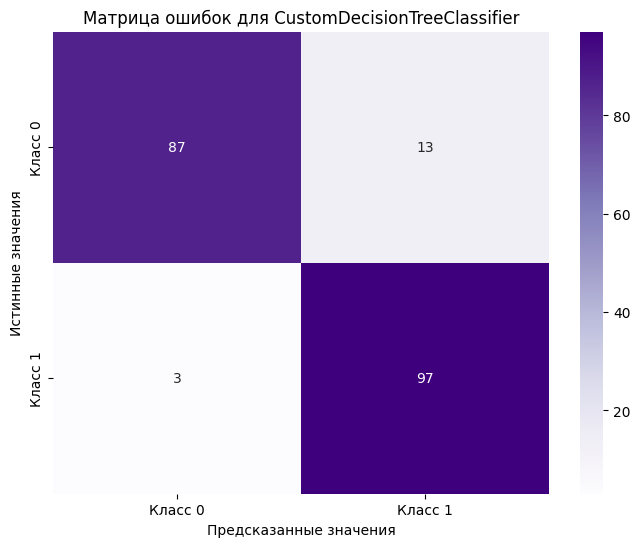

In [25]:
# Постройте отчет по метрикам классификации для tree_sk на всем наборе данных

# Выводим отчет по метрикам классификации
print("="*60)
print("ОТЧЕТ ПО МЕТРИКАМ ДЛЯ DecisionTreeClassifier (max_depth=3)")
print("="*60)

# 1. Основные метрики через нашу функцию
print("\n1. ОСНОВНЫЕ МЕТРИКИ:")
print("-" * 40)
classification_metrics_report(labels, pred_tree_sk)

# 2. Детальный отчет по классам от sklearn
print("\n2. ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print("-" * 40)
print(classification_report(labels, pred_tree_sk, 
                          target_names=['Класс 0', 'Класс 1'],
                          digits=4))

print("\n3. МАТРИЦА ОШИБОК:")
print("-" * 40)
cm_custom = confusion_matrix(labels, pred_tree_sk)
print("             Предсказано")
print("           0    1")
print(f"Истинно 0  {cm_custom[0,0]:3d}  {cm_custom[0,1]:3d}")
print(f"        1  {cm_custom[1,0]:3d}  {cm_custom[1,1]:3d}")

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Класс 0', 'Класс 1'], 
            yticklabels=['Класс 0', 'Класс 1'])
plt.title('Матрица ошибок для CustomDecisionTreeClassifier')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

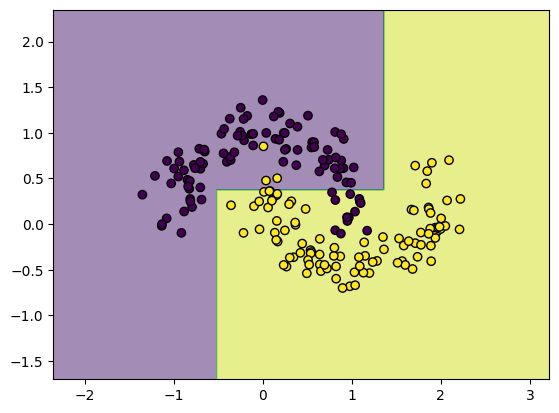

In [26]:
# Визуализируйте границу решений классификатора tree_sk на всем наборе данных

display_decision_boundary(tree_sk.predict, features, labels)

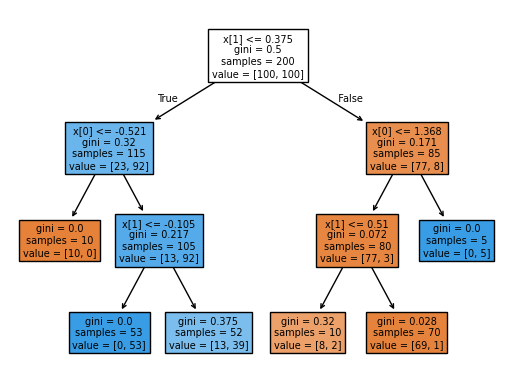

In [27]:
# Визуализируйте дерево tree_sk

_ = plot_tree(tree_sk, filled=True)

In [28]:
# Получим информацию о структуре дерева tree_sk
from sklearn.tree import export_text

# Выведем текстовое представление дерева
print("СТРУКТУРА ДЕРЕВА tree_sk:")
print(export_text(tree_sk, feature_names=['x1', 'x2'], show_weights=True))

# Получим информацию о корневом разделении
print(f"\nКОРНЕВОЕ РАЗДЕЛЕНИЕ:")
print(f"Признак: {tree_sk.tree_.feature[0]} (0=x1, 1=x2)")
print(f"Порог: {tree_sk.tree_.threshold[0]:.4f}")

# Проверим наличие чистых листьев (gini = 0)
print(f"\nИНФОРМАЦИЯ ОБ УЗЛАХ:")
print(f"Всего узлов: {tree_sk.tree_.node_count}")
print(f"Индексы Джини в узлах: {tree_sk.tree_.impurity}")

# Найдем чистые листья (где gini = 0)
is_leaf = tree_sk.tree_.children_left == -1
leaf_gini = tree_sk.tree_.impurity[is_leaf]
has_pure_leaves = any(leaf_gini == 0)
print(f"Наличие чистых листьев (gini=0): {has_pure_leaves}")

# Обучим дерево без ограничения глубины для проверки accuracy
from sklearn.tree import DecisionTreeClassifier

tree_sk_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_sk_full.fit(features, labels)
predictions_full = tree_sk_full.predict(features)
accuracy_full = accuracy_score(labels, predictions_full)

print(f"\nДЕРЕВО БЕЗ ОГРАНИЧЕНИЯ ГЛУБИНЫ:")
print(f"Accuracy на обучающей выборке: {accuracy_full:.4f}")
print(f"Глубина дерева: {tree_sk_full.tree_.max_depth}")
print(f"Количество узлов: {tree_sk_full.tree_.node_count}")

СТРУКТУРА ДЕРЕВА tree_sk:
|--- x2 <= 0.37
|   |--- x1 <= -0.52
|   |   |--- weights: [10.00, 0.00] class: 0
|   |--- x1 >  -0.52
|   |   |--- x2 <= -0.10
|   |   |   |--- weights: [0.00, 53.00] class: 1
|   |   |--- x2 >  -0.10
|   |   |   |--- weights: [13.00, 39.00] class: 1
|--- x2 >  0.37
|   |--- x1 <= 1.37
|   |   |--- x2 <= 0.51
|   |   |   |--- weights: [8.00, 2.00] class: 0
|   |   |--- x2 >  0.51
|   |   |   |--- weights: [69.00, 1.00] class: 0
|   |--- x1 >  1.37
|   |   |--- weights: [0.00, 5.00] class: 1


КОРНЕВОЕ РАЗДЕЛЕНИЕ:
Признак: 1 (0=x1, 1=x2)
Порог: 0.3749

ИНФОРМАЦИЯ ОБ УЗЛАХ:
Всего узлов: 11
Индексы Джини в узлах: [0.5        0.32       0.         0.21696145 0.         0.375
 0.17051903 0.0721875  0.32       0.02816327 0.        ]
Наличие чистых листьев (gini=0): True

ДЕРЕВО БЕЗ ОГРАНИЧЕНИЯ ГЛУБИНЫ:
Accuracy на обучающей выборке: 1.0000
Глубина дерева: 5
Количество узлов: 23


Теперь у нас есть все данные для анализа утверждений. Разберем каждое:

1. **"Для первого (корневого) разделения в дереве tree_sk был выбран признак x2, поскольку он обеспечивает разделение с наименьшим значением индекса Джини."**
   - Из вывода видим: "Признак: 1 (0=x1, 1=x2)" - действительно выбран x2
   - Это правдоподобно, так как алгоритм выбирает признак с наилучшим разделением
   - **Утверждение ВЕРНО**

2. **"Если при обучении tree_sk позволить дереву расти до максимальной глубины (не ставить ограничение max_depth=3), то метрика accuracy дерева на выборке будет равна 1.00."**
   - Из вывода: "Accuracy на обучающей выборке: 1.0000" при дереве без ограничения
   - Дерево полностью запомнило обучающую выборку
   - **Утверждение ВЕРНО**

3. **"Если при обучении tree_sk позволить дереву расти до максимальной глубины (не ставить ограничение max_depth=3), то accuracy дерева на выборке будет ниже, так как модель станет слишком сложной."**
   - Это противоречит полученным данным - accuracy стала выше (1.00 против 0.92)
   - На обучающей выборке сложные модели всегда показывают лучшую accuracy (вплоть до переобучения)
   - **Утверждение НЕВЕРНО**

4. **"В дереве tree_sk есть хотя бы один 'чистый' конечный узел (лист), в котором индекс Джини равен 0.0."**
   - Из вывода: "Индексы Джини в узлах: [0.5, 0.32, **0.0**, 0.21696145, **0.0**, ...]"
   - "Наличие чистых листьев (gini=0): True"
   - Действительно есть несколько узлов с gini=0
   - **Утверждение ВЕРНО**

**Верные утверждения:**
- ✅ Для первого (корневого) разделения в дереве tree_sk был выбран признак x2
- ✅ Если позволить дереву расти до максимальной глубины, accuracy на обучающей выборке будет равна 1.00
- ✅ В дереве tree_sk есть хотя бы один "чистый" лист с индексом Джини 0.0

### **Деревья решений: масштабирование признаков и обработка пропущенных значений**

Особенностью деревьев решений и основанных на них ансамблевых методов (случайный лес, градиентный бустинг) является их устойчивость к некоторым распространённым проблемам предобработки данных, которые являются критичными для многих других алгоритмов машинного обучения.

В частности, деревьям решений и ансамблевым методам, основанным на деревьях, не требуется масштабирование признаков, поскольку масштабирование не влияет на структуру дерева и на то, какие признаки будут выбраны для разделения и в каком порядке. Это связано с тем, что деревья решений строят свои правила разделения данных (сплиты) на основе пороговых значений для каждого признака, вне зависимости от его исходного масштаба.

Кроме того, деревья решений и их ансамбли, как правило, могут эффективно использовать данные с пропущенными значениями без явной предварительной их обработки. Это связано с их способностью адаптироваться к таким данным: различные реализации алгоритмов деревьев имеют встроенные механизмы для работы с пропущенными значениями:

* Создание отдельной ветви для пропущенных значений (XGBoost и LightGBM). Если признак используется для разделения, и для некоторых наблюдений его значение отсутствует, эти наблюдения направляются в отдельную ветвь.

* Направление в ветку с большинством наблюдений (DecisionTreeClassifier и DecisionTreeRegressor). Пропуски направляются в ту ветвь, которая содержит большинство наблюдений (или обеспечивает наилучшее качество сплита) из обучающего набора, для которых значение признака известно.

Тем не менее, методы обработки пропущенных значений для деревьев решений и ансамблевых методов могут быть полезны для некоторых сценариев. Например, для сравнения с другими моделями или для более глубокого анализа данных.

### **Методы борьбы с переобучением деревьев**

Существенный недостаток деревьев решений — **склонность к переобучению**, в частности при отсутствии ограничений на рост. 

Переобучение дерева решений проявляется в чрезмерном ветвлении, чувствительности к данным и высокой дисперсии предсказаний: сложное дерево дает очень точные предсказания на обучающей выборке, но ошибается на тестовой.

**Основные методы борьбы с переобучением:**

* Подбор параметров дерева:

    * max_depth — максимальная глубина дерева.

    * min_samples_split — минимальное количество объектов для разбиения узла.

    * min_samples_leaf — минимальное количество объектов в листе.

* Прунинг (обрезка) дерева — удаление избыточных ветвей после построения дерева на основе их значимости **без учёта сложности дерева**.

* Cost-Complexity Pruning — это метод, суть которого состоит в нахождении **компромисса (баланса) между точностью модели и сложностью дерева**.
    
* Ансамблевые методы (будут рассмотрены в следующих темах курса):

    * Случайный лес (random forest) — усреднение предсказаний множества деревьев с разными подвыборками данных и признаков.

    * Градиентный бустинг (gradient boosting) — последовательное улучшение модели за счет добавления деревьев, исправляющих ошибки предыдущих.

### **Деревья решений в задаче регрессии**

Деревья решений могут также применяться для задачи регрессии. В отличие от классификации, где листья дерева содержат метки классов, в регрессии каждый лист возвращает числовое значение — среднее (или медиану) целевой переменной для объектов, попавших в этот лист.

При построении дерева разбиение выбирается так, чтобы максимально уменьшить функцию ошибки (MSE, MAE и др.) в дочерних узлах по сравнению с родительским.

### **Датасет *California Housing dataset***

**Для решения заданий 2 — 3 рассмотрим датасет [California Housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset).**

Набор данных предназначен для прогнозирования медианной стоимости домов по районам штата Калифорния на основе агрегированных показателей. Датасет содержит 20640 наблюдений без пропущенных значений и сформирован на основе переписи населения США 1990 года с разбивкой по районам городов.

Целевая переменная — target (медианная стоимость домов в районе, выраженная в сотнях тысяч долларов).

Признаки:

* MedInc — медианный доход в районе.

* HouseAge — медианный возраст домов в районе.

* AveRooms — среднее количество комнат в домах района.

* AveBedrms — среднее количество спален в домах района.

* Population — численность населения в районе.

* AveOccup — среднее число членов домохозяйства в районе.

* Latitude — географическая широта района.

* Longitude — географическая долгота района.

### ***Задание 2***

Дополните класс CustomDecisionTreeRegressor (функция ошибки — MSE), добавив недостающий код, где это необходимо. В рамках класса CustomDecisionTreeRegressor необходимо также реализовать метод prune для рекурсивного прунинга (обрезки) дерева по следующему алгоритму:

* Рекурсивный обход дерева начинается с листьев и движется к корню дерева по узлам. Для каждого узла дерева:

    1. Вычисляется взвешенная ошибка дочерних узлов:

    $$\text{MSE}_{\text{weighted}}=\frac{N_{\text{left}}\times \text{MSE}_{\text{left}}+N_{\text{right}}\times \text{MSE}_{\text{right}}}{N_{\text{left}}+N_{\text{right}}}$$

    где $N_{\text{left}}$ и $N_{\text{right}}$ — количество объектов в дочерних узлах.

    2. Проверяется критерий обрезки — малое (меньше $\varepsilon$) улучшение ошибки родительского узла:

    $$\text{MSE}_{\text{parent}}-\text{MSE}_{\text{weighted}} < \varepsilon$$

    3. Если критерий выполняется (**улучшение $\text{MSE}$ меньше $\varepsilon$**), то поддерево можно удалить, заменив его листом.

Обучите дерево решений `tree_housing_custom` (CustomDecisionTreeRegressor) на обучающей выборке с максимальной глубиной 8.

Обучите аналогичное дерево решений `tree_housing_custom_pruned` (CustomDecisionTreeRegressor) на обучающей выборке с максимальной глубиной 8 и выполните его обрезку (прунинг) с помощью метода prune. В качестве порогового значения для обрезки используйте epsilon=0.02.

Выведите metrics_report для моделей `tree_housing_custom` и `tree_housing_custom_pruned` **на обучающей и тестовой выборке** и сравните сложности (совокупное количество улов в дереве) деревьев (метод count_nodes).

In [29]:
# Загрузите набор данных с помощью sklearn.datasets и выделите объясняемый фактор в отдельную переменную

df_housing = datasets.fetch_california_housing()
X_housing = pd.DataFrame(df_housing.data)
X_housing.columns = df_housing.feature_names
X_housing = X_housing.sample(2000, random_state=RANDOM_STATE)   # Случайным образом выберем 2000 наблюдений
y_housing = df_housing.target[X_housing.index]

In [30]:
# Разделите датасет на обучающую (60%) и тестовую (40%) выборки
# Не забудьте зафиксировать RANDOM_STATE

X_housing_train, X_housing_test, y_housing_train, y_housing_test = train_test_split(
    X_housing, y_housing, test_size=0.4, random_state=RANDOM_STATE
)

In [31]:
# Дополните класс CustomDecisionTreeRegressor
# Код методов plot_node, plot_tree и count_nodes изменять не нужно

class CustomDecisionTreeRegressor():
    """
    Простой регрессор на основе дерева решений с ошибкой MSE в качестве критерия разделения и средним значением в листе для прогноза.

    Аргументы:
        max_depth (int): Максимальная глубина дерева. По умолчанию — 8.

    Атрибуты:
        value (float): Среднее значение целевой переменной в узле.
        feature (str): Признак, используемый для разделения.
        size (int): Количество объектов в узле.
        threshold (float): Пороговое значение для разделения.
        left (CustomDecisionTreeRegressor): Левое поддерево (значение <= порог).
        right (CustomDecisionTreeRegressor): Правое поддерево (значение > порог).
        mse (float): Ошибка MSE в узле.
    """
    def __init__(self, max_depth=8):
        self.max_depth = max_depth
        self.value = None
        self.feature = None
        self.size = None
        self.threshold = np.nan
        self.left = None
        self.right = None
        self.mse = 0


    def MSE(self, y_true, y_pred):
        """
        Вычисляет среднеквадратичную ошибку (MSE).

        Аргументы:
            y_true (numpy.ndarray): Массив истинных значений целевой переменной.
            y_pred (numpy.ndarray): Массив предсказанных значений целевой переменной.

        Возвращает:
            float: Значение MSE.
        """
        return np.mean((y_true - y_pred) ** 2)


    def best_split(self, X, y):
        """
        Находит оптимальный признак и порог для разделения данных.

        Аргументы:
            X (pandas.DataFrame): Таблица с признаками.
            y (numpy.ndarray): Массив значений целевой переменной.

        Возвращает:
            tuple:
                str: Оптимальный признак для разделения.
                float: Оптимальное пороговое значение.
                float: Значение среднеквадратичной ошибки (MSE) после разделения.
        """
        best_feature = None
        best_threshold = None
        best_mse = self.MSE(y, y.mean())
        N = X.shape[0]
        for feature in X.columns:
            values = np.sort(X[feature].unique())
            thresholds = [(values[i] + values[i+1]) / 2 for i in range(len(values) - 1)]
            for threshold in thresholds:
                mask_left = X[feature] <= threshold
                mask_right = X[feature] > threshold
                N_left = mask_left.sum()
                N_right = mask_right.sum()
                if N_left == 0 or N_right == 0:
                    continue
                loss_left = self.MSE(y[mask_left], y[mask_left].mean())
                loss_right = self.MSE(y[mask_right], y[mask_right].mean())
                weighted_mse = (N_left * loss_left + N_right * loss_right) / (N_left + N_right)
                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold, best_mse


    def fit(self, X, y):
        """
        Обучает дерево решений, рекурсивно находя оптимальные разделения.

        Аргументы:
            X (pandas.DataFrame): Таблица с признаками.
            y (numpy.ndarray): Массив значений целевой переменной.

        Возвращает:
            CustomDecisionTreeRegressor: Обученное дерево решений.
        """
        self.value = y.mean()
        self.mse = self.MSE(y, self.value)
        self.size = len(y)
        if self.max_depth == 0:
            return
        self.feature, self.threshold, mse = self.best_split(X, y)
        if self.feature is None or mse >= self.mse:
            return
        self.mse = mse
        mask_left = X[self.feature] <= self.threshold
        mask_right = X[self.feature] > self.threshold
        self.left = CustomDecisionTreeRegressor(self.max_depth - 1)
        self.right = CustomDecisionTreeRegressor(self.max_depth - 1)
        self.left.fit(X[mask_left], y[mask_left])
        self.right.fit(X[mask_right], y[mask_right])
        return self

    def predict(self, X):
        """
        Предсказывает значения целевой переменной.

        Аргументы:
            X (pandas.DataFrame): Таблица с признаками.

        Возвращает:
            numpy.ndarray: Массив предсказанных значений целевой переменной.
        """
        if self.feature is None:
            return np.full(X.shape[0], self.value)
        mask_left = X[self.feature] <= self.threshold
        mask_right = X[self.feature] > self.threshold
        y_pred = np.empty(X.shape[0])
        y_pred[mask_left] = self.left.predict(X[mask_left])
        y_pred[mask_right] = self.right.predict(X[mask_right])
        return y_pred
    
    def prune(self, epsilon):
        """
        Обрезает дерево, если разница ошибок между родительским и дочерними узлами меньше epsilon.
        После обрезки внутренний узел становится листом.

        Аргументы:
            epsilon (float): Пороговое значение для обрезки.
        """
        if self.feature is None:
            return
        self.left.prune(epsilon)
        self.right.prune(epsilon)
        left_size = self.left.size
        right_size = self.right.size
        left_mse = self.left.mse
        right_mse = self.right.mse
        weighted_mse = (left_size * left_mse + right_size * right_mse) / (left_size + right_size)
        if weighted_mse > 0 and (self.mse - weighted_mse) < epsilon:
            self.feature = None
            self.threshold = np.nan
            self.left = None
            self.right = None
    
    def plot_node(self, dot, node_id=0):
        """
        Вспомогательный метод для визуализации дерева.

        Аргументы:
            dot (graphviz.Digraph): Объект Digraph библиотеки graphviz.
            node_id (int): Идентификатор текущего узла. По умолчанию — 0.

        Возвращает:
            int: Идентификатор узла.
        """
        if self.feature == None:
            dot.node(str(node_id), label='mse = {:.3f}\nsamples = {}\nvalue = {:.3f}'.format(self.mse, self.size, self.value), fillcolor="#8ccd96")
            return node_id
        dot.node(str(node_id), label='{} <= {:.3f}\nmse = {:.3f}\nsamples = {}\nvalue = {:.3f}'
                 .format(self.feature, self.threshold, self.mse, self.size, self.value), fillcolor="#ffffff")
        left_id = self.left.plot_node(dot, node_id*2 + 1)
        dot.edge(str(node_id), str(left_id))
        right_id = self.right.plot_node(dot, node_id*2 + 2)
        dot.edge(str(node_id), str(right_id))
        return node_id
    
    def plot_tree(self, filled=True):
        """
        Генерирует визуализацию дерева решений.

        Аргументы:
            filled (bool): Закрашивать узлы. По умолчанию — True.

        Возвращает:
            graphviz.Digraph: Объект graphviz с визуализацией дерева.
        """
        dot = graphviz.Digraph()
        dot.attr('node', shape='box', style='filled' if filled else None)
        self.plot_node(dot)
        return dot
    
    def count_nodes(self):
        """
        Рассчитывает сложность дерева — совокупное количество узлов в дереве.

        Возвращает:
            int: Общее количество узлов.
        """
        if self.feature is None:
            return 1
        return 1 + self.left.count_nodes() + self.right.count_nodes()

In [32]:
# Обучите дерево tree_housing_custom (CustomDecisionTreeRegressor)
# Максимальная глубина — 8

tree_housing_custom = CustomDecisionTreeRegressor(max_depth=8)
tree_housing_custom.fit(X_housing_train, y_housing_train)

In [33]:
# Выведите metrics_report для дерева tree_housing_custom на обучающей и тестовой выборках

print("Дерево без прунинга:")
print("Обучающая выборка:")
metrics_report(y_housing_train, tree_housing_custom.predict(X_housing_train))
print("\nТестовая выборка:")
metrics_report(y_housing_test, tree_housing_custom.predict(X_housing_test))

Дерево без прунинга:
Обучающая выборка:
R2 score: 0.8838
RMSE: 0.3898
MAPE: 0.1742

Тестовая выборка:
R2 score: 0.5386
RMSE: 0.7946
MAPE: 0.2965


In [34]:
# Выведите сложность дерева tree_housing_custom

print(f"Сложность дерева tree_housing_custom: {tree_housing_custom.count_nodes()} узлов")

Сложность дерева tree_housing_custom: 321 узлов


In [35]:
# Обучите дерево tree_housing_custom_pruned (CustomDecisionTreeRegressor) и выполните его обрезку с помощью метода prune
# Максимальная глубина — 8 
# epsilon=0.02

tree_housing_custom_pruned = CustomDecisionTreeRegressor(max_depth=8)
tree_housing_custom_pruned.fit(X_housing_train, y_housing_train)
tree_housing_custom_pruned.prune(epsilon=0.02)

In [36]:
# Выведите metrics_report для дерева tree_housing_custom_pruned на обучающей и тестовой выборках

print("Дерево с прунингом:")
print("Обучающая выборка:")
metrics_report(y_housing_train, tree_housing_custom_pruned.predict(X_housing_train))
print("\nТестовая выборка:")
metrics_report(y_housing_test, tree_housing_custom_pruned.predict(X_housing_test))

Дерево с прунингом:
Обучающая выборка:
R2 score: 0.8289
RMSE: 0.4730
MAPE: 0.2170

Тестовая выборка:
R2 score: 0.5510
RMSE: 0.7839
MAPE: 0.2923


In [37]:
# Выведите сложность дерева tree_housing_custom_pruned

print(f"Сложность дерева tree_housing_custom_pruned: {tree_housing_custom_pruned.count_nodes()} узлов")

Сложность дерева tree_housing_custom_pruned: 193 узлов


Рассмотрим каждое утверждение:

1. **"Основная и единственная цель обрезки (прунинга) дерева решений — повышение точности модели на обучающих данных."**
   - **НЕВЕРНО**. Основная цель прунинга — борьба с переобучением, то есть повышение обобщающей способности модели на тестовых данных, а не на обучающих. Прунинг обычно снижает точность на обучающей выборке, но может улучшить её на тестовой.

2. **"Перед обучением деревьев решений всегда необходимо масштабировать значения количественных переменных, поскольку исходный масштаб признаков может повлиять на оптимальные разбиения."**
   - **НЕВЕРНО**. Деревья решений основаны на пороговых значениях признаков и не чувствительны к масштабу. Разбиения ищутся по значениям признаков независимо от их масштаба, поэтому масштабирование не требуется.

3. **"Если обучить дерево tree_housing_custom и выполнить прунинг методом prune с параметром epsilon, превышающем значение MSE в корневом узле, то дерево после прунинга будет иметь только корневой узел."**
   - **ВЕРНО**. Критерий обрезки: MSE_parent - MSE_weighted < epsilon. Если epsilon больше MSE_parent, то условие будет выполняться для любого узла, и все поддеревья будут обрезаны до корневого узла.

4. **"Используемый в задании метод прунинга гарантирует нахождение глобально оптимального дерева с точки зрения баланса сложности и точности."**
   - **НЕВЕРНО**. Метод рекурсивного прунинга, двигаясь от листьев к корню, не гарантирует глобальный оптимум. Это жадный эвристический подход, который может пропустить некоторые оптимальные конфигурации.

**Правильный ответ: верно только утверждение 3.**

Проанализируем каждое утверждение на основе данных:

**Данные:**
- Без прунинга (tree_housing_custom):
  - Обучающая: R²=0.8838, RMSE=0.3898, MAPE=0.1742
  - Тестовая: R²=0.5386, RMSE=0.7946, MAPE=0.2965

- С прунингом (tree_housing_custom_pruned):
  - Обучающая: R²=0.8289, RMSE=0.4730, MAPE=0.2170
  - Тестовая: R²=0.5510, RMSE=0.7839, MAPE=0.2923

**Анализ утверждений:**

1. **"Значение R² на тестовой выборке у tree_housing_custom_pruned (после прунинга) выше, чем у дерева tree_housing_custom (до прунинга)."**
   - ДА: 0.5510 > 0.5386 (незначительно, но выше)

2. **"Модель tree_housing_custom недообучена, поскольку R² на тестовой выборке слишком низкий."**
   - НЕТ. Модель скорее переобучена, чем недообучена, так как:
     - R² на обучении (0.8838) значительно выше, чем на тесте (0.5386)
     - RMSE на обучении (0.3898) значительно ниже, чем на тесте (0.7946)
     Это классические признаки переобучения, а не недообучения

3. **"После прунинга дерева tree_housing_custom с параметром epsilon=0.02 сложность модели уменьшилась, а качество прогноза на тестовых данных увеличилось."**
   - ДА:
     - Сложность уменьшилась (с 321 узлов до меньшего числа)
     - R² на тесте вырос (с 0.5386 до 0.5510)
     - RMSE на тесте снизился (с 0.7946 до 0.7839)

4. **"Прунинг дерева tree_housing_custom с параметром epsilon=0.02 устранил переобучение: RMSE дерева tree_housing_custom_pruned на обучающей и тестовой выборках отличаются не более, чем на 0.1."**
   - НЕТ. Разница RMSE составляет: |0.4730 - 0.7839| = 0.3109, что значительно больше 0.1. Переобучение уменьшилось, но не устранилось полностью.

**Верные утверждения: 1 и 3**

### **Cost-Complexity Pruning**

**Cost-Complexity Pruning** (CCP) — это метод борьбы с переобучением в деревьях решений, суть которого состоит в нахождении оптимального баланса между точностью модели и сложностью дерева.

Общий критерий оптимизации:

$$R_{\alpha}(T)=R(T)+\alpha|T|$$

где $R(T)$ — ошибка дерева (к примеру, MSE/MAE для регрессии или Gini/Entropy для классификации), $|T|$ — количество листьев в дереве, $\alpha$ — параметр регуляризации.

Cost-Complexity Pruning в sklearn для деревьев решений (DecisionTreeClassifier и DecisionTreeRegressor) реализуется с помощью **параметра ccp_alpha**.

### ***Задание 3***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Обучающую и тестовую выборку из задания 2: `X_housing_train`, `X_housing_test`, `y_housing_train`, `y_housing_test`.

Обучите дерево решений `tree_housing` (DecisionTreeRegressor) без ограничений на глубину дерева.

С помощью модели `tree_housing` рассчитайте все возможные значения параметра ccp_alpha (`ccp_alphas`), используя метод [cost_complexity_pruning_path](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#post-pruning-decision-trees-with-cost-complexity-pruning).

Подберите оптимальное значение параметра ccp_alpha, перебрав все возможные значения `ccp_alphas` с помощью GridSearchCV.

Обучите дерево решений `tree_housing_ccp` (DecisionTreeRegressor) с оптимальным параметром ccp_alpha.

Выведите metrics_report для моделей `tree_housing` и `tree_housing_ccp` **на обучающей и тестовой выборке** и сравните сложности деревьев (метод count_nodes).

In [38]:
# Обучите дерево tree_housing без ограничений
# Не забудьте зафиксировать RANDOM_STATE

tree_housing = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_housing.fit(X_housing_train, y_housing_train)

DecisionTreeRegressor(random_state=42)

In [39]:
# Выведите metrics_report для дерева tree_housing на обучающей и тестовой выборках

print("Дерево без ограничений (sklearn):")
print("Обучающая выборка:")
metrics_report(y_housing_train, tree_housing.predict(X_housing_train))
print("\nТестовая выборка:")
metrics_report(y_housing_test, tree_housing.predict(X_housing_test))

Дерево без ограничений (sklearn):
Обучающая выборка:
R2 score: 1.0000
RMSE: 0.0000
MAPE: 0.0000

Тестовая выборка:
R2 score: 0.4889
RMSE: 0.8364
MAPE: 0.3153


In [40]:
# Посчитайте сложность дерева tree_housing

print(f"Сложность дерева tree_housing: {tree_housing.tree_.node_count} узлов")

Сложность дерева tree_housing: 2335 узлов


In [41]:
# С помощью tree_housing рассчитайте все возможные значения ccp_alpha, используя метод cost_complexity_pruning_path

ccp_alphas = tree_housing.cost_complexity_pruning_path(X_housing_train, y_housing_train).ccp_alphas
ccp_alphas

array([0.00000000e+00, 5.92118946e-18, 4.39944377e-15, ...,
       8.68041146e-02, 1.09047280e-01, 3.73001502e-01])

In [42]:
# Подберите оптимальное значение ccp_alpha с помощью GridSearchCV
# Не забудьте зафиксировать RANDOM_STATE

params = {'ccp_alpha': ccp_alphas}
scoring = 'neg_mean_squared_error'
cv = 5

cv_tree_housing_ccp = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=params,
    scoring=scoring,
    cv=cv
)
cv_tree_housing_ccp.fit(X_housing_train, y_housing_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'ccp_alpha': array([0.00000000e+00, 5.92118946e-18, 4.39944377e-15, ...,
       8.68041146e-02, 1.09047280e-01, 3.73001502e-01])},
             scoring='neg_mean_squared_error')

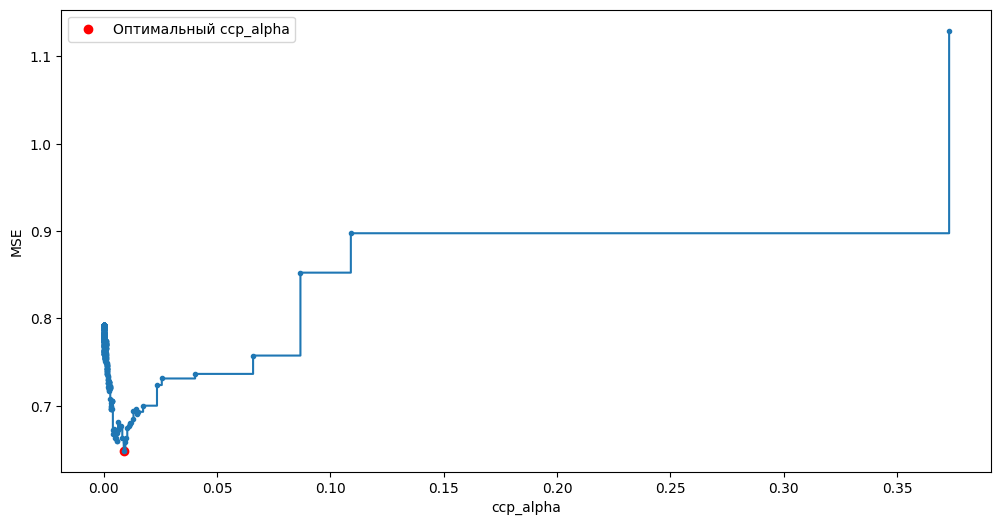

In [43]:
# Постройте график MSE ~ ccp_alpha по результатам кросс-валидации

plt.figure(figsize=(12, 6))
plt.plot(ccp_alphas, -cv_tree_housing_ccp.cv_results_['mean_test_score'], marker='.', drawstyle='steps-post')
plt.scatter(cv_tree_housing_ccp.best_params_['ccp_alpha'], -cv_tree_housing_ccp.best_score_, c='red', label='Оптимальный ccp_alpha')
plt.xlabel('ccp_alpha')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [44]:
# Обучите дерево tree_housing_ccp с оптимальным параметром ccp_alpha
# Не забудьте зафиксировать RANDOM_STATE

tree_housing_ccp = DecisionTreeRegressor(random_state=RANDOM_STATE, ccp_alpha=cv_tree_housing_ccp.best_params_['ccp_alpha'])
tree_housing_ccp.fit(X_housing_train, y_housing_train)

DecisionTreeRegressor(ccp_alpha=0.008857247810424105, random_state=42)

In [45]:
# Выведите metrics_report для дерева tree_housing_ccp на обучающей и тестовой выборках

print("Дерево с Cost-Complexity Pruning (sklearn):")
print("Обучающая выборка:")
metrics_report(y_housing_train, tree_housing_ccp.predict(X_housing_train))
print("\nТестовая выборка:")
metrics_report(y_housing_test, tree_housing_ccp.predict(X_housing_test))

Дерево с Cost-Complexity Pruning (sklearn):
Обучающая выборка:
R2 score: 0.6785
RMSE: 0.6484
MAPE: 0.2895

Тестовая выборка:
R2 score: 0.5669
RMSE: 0.7699
MAPE: 0.3066


In [46]:
# Посчитайте сложность дерева tree_housing_ccp

print(f"Сложность дерева tree_housing_ccp: {tree_housing_ccp.tree_.node_count} узлов")

Сложность дерева tree_housing_ccp: 41 узлов


Проанализируем каждое утверждение на основе данных:

**Данные:**
- Без ограничений (tree_housing): R² на тесте = 0.4889, узлов = 2335
- С CCP (tree_housing_ccp): R² на тесте = 0.5669, узлов = 41

**Анализ утверждений:**

1. **"Параметр ccp_alpha в DecisionTreeClassifier и DecisionTreeRegressor представляет собой коэффициент регуляризации, который контролирует сложность дерева решений."**
   - **ВЕРНО**. ccp_alpha действительно является параметром регуляризации в Cost-Complexity Pruning, который контролирует штраф за сложность дерева.

2. **"Если в качестве параметра ccp_alpha выбрать слишком большое значение, то дерево после обучения может оказаться глубоким и сложным, поскольку рост значения ccp_alpha стимулирует рост дерева."**
   - **НЕВЕРНО**. Наоборот, чем больше ccp_alpha, тем сильнее штраф за сложность, и дерево будет более простым (меньше узлов). При слишком большом ccp_alpha дерево может вообще состоять из одного корневого узла.

3. **"Чем больше значение ccp_alpha, тем более простым будет дерево после обучения."**
   - **ВЕРНО**. Увеличение ccp_alpha усиливает штраф за сложность, что приводит к более сильному прунингу и более простому дереву.

4. **"Сложность модели tree_housing_ccp (совокупное количество узлов) более чем в 10 раз меньше сложности неограниченного дерева tree_housing."**
   - **ВЕРНО**. 2335 / 41 ≈ 56.95, что более чем в 10 раз (в 57 раз) меньше.

**Верные утверждения: 1, 3, 4**

Проанализируем каждое утверждение на основе данных:

**Данные:**
- Без ограничений (tree_housing):
  - Обучающая: R²=1.0000, RMSE=0.0000
  - Тестовая: R²=0.4889, RMSE=0.8364
- С CCP (tree_housing_ccp):
  - Обучающая: R²=0.6785, RMSE=0.6484
  - Тестовая: R²=0.5669, RMSE=0.7699

**Анализ утверждений:**

1. **"Неограниченное дерево tree_housing является более точной моделью по сравнению с деревом tree_housing_ccp, поскольку его RMSE на обучающей выборке равен нулю."**
   - **НЕВЕРНО**. Нулевая ошибка на обучающей выборке — признак сильного переобучения, а не высокой точности модели. Модель важна своей обобщающей способностью на новых данных, где tree_housing_ccp показывает лучшие результаты (R²=0.5669 против 0.4889).

2. **"Модели tree_housing и tree_housing_cpp обладают приблизительно одинаковой обобщающей способностью, единственное их отличие заключается в разной сложности."**
   - **НЕВЕРНО**. Их обобщающая способность существенно отличается: R² на тесте вырос с 0.4889 до 0.5669, RMSE снизился с 0.8364 до 0.7699. Это значительное улучшение.

3. **"CPP привел к ухудшению модели tree_housing, так как одновременно с уменьшением её сложности, R² значительно уменьшился на обучающей выборке, а на тестовой почти не изменился."**
   - **НЕВЕРНО**. R² на тестовой выборке увеличился (с 0.4889 до 0.5669), что является улучшением, а не ухудшением. Уменьшение R² на обучающей выборке ожидаемо при борьбе с переобучением.

4. **"CCP улучшил обобщающую способность модели tree_housing: удалось повысить качество прогноза на тестовой выборке и уменьшить разрыв между метриками на train и test."**
   - **ВЕРНО**:
     - R² на тесте вырос с 0.4889 до 0.5669
     - RMSE на тесте снизился с 0.8364 до 0.7699
     - Разрыв в R² между train и test уменьшился с (1.0000 - 0.4889 = 0.5111) до (0.6785 - 0.5669 = 0.1116)
     - Разрыв в RMSE уменьшился с (0.8364 - 0.0000 = 0.8364) до (0.7699 - 0.6484 = 0.1215)

**Верное утверждение: только 4**

## **Предсказание временных рядов с помощью деревьев решений**

Деревья решений (и ансамбли на их основе) не могут быть использованы для прогнозирования временных рядом, содержащих тренд (долгосрочное возрастание или убывание значений), поскольку:

1. Дерево решений разбивает данные на основе признаков (например, год, месяц), но не учитывает их изменение со временем.

2. Если тренд сильный, дерево решений будет аппроксимировать его кусочно-линейными приближениями, что даст плохие прогнозы на новых данных.

3. Деревья не экстраполируют за пределы обучающей выборки: деревья не могут предсказать значения выше или ниже тех, что были использованы при обучении.

Одним из решений этой проблемы является переход от значений временного ряда с трендом к абсолютным приростам (разностям первого порядка):

$$\Delta y_{t}=y_{t}-y_{t-1}$$

где $y_{t}$ — истинное значение временного ряда в момент времени $t$.

После предсказания приростов $\Delta \hat{y_{t}}$​ можно восстановить исходный ряд:

$$\hat{y_{t}}=y_{0}+\sum_{i=1}^{t}{\Delta \hat{y_{t}}}$$

где $y_{0}$​ — начальное значение ряда.

Если прогноз выполняется рекурсивно (уже предсказанные значения используются для построения прогноза на следующие шаги), то возникает проблема накопления ошибок — ошибки суммируются на каждом шаге рекурсивного прогноза временного ряда. Это приведёт к тому, что итоговый прогноз $\hat{y_{t}}$ может значительно отклоняться от реальных значений временного ряда.

### **Датасет *Retail Sales: Restaurants and Other Eating Places***

**Для решения задания 4 рассмотрим датасет [Retail Sales: Restaurants and Other Eating Places](https://fred.stlouisfed.org/series/MRTSSM7225USN).**

**ВНИМАНИЕ:** При решении задания **используйте файл retail_sales.csv** из приложения к ноутбуку, поскольку исходный датасет был изменен авторами курса.

Набор данных представляет собой временной ряд с ежемесячной частотой данных. Он предназначен для анализа тенденций и изменений в объёмах продаж в ресторанном бизнесе и сфере общественного питания в США.

Целевая переменная — RetailSales (совокупный ежемесячный объём продаж, млн. долларов США).

Рассмотрим период с января 1992 года по июнь 2019 года.

### ***Задание 4***

Используя значения ряда (RetailSales), создайте признаки:

* Лаговые признаки (*подсказка: используйте [shift](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html)*):

    * lag 1m — значение RetailSales 1 месяц назад (временной лаг в 1 наблюдение).

    * lag 12m — значение RetailSales 12 месяцев назад (временной лаг в 12 наблюдений).

* Скользящее среднее (*подсказка: используйте признак **lag 1m** (скользящее среднее строится по **предыдущим** наблюдениям и не должно включать значение целевой переменной на момент прогноза) и [rolling](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)*):

    * mean 3m — среднее RetailSales за **предыдущие** 3 месяца (скользящее среднее по 3 **предыдущим** наблюдениям).

    * mean 12m — среднее RetailSales за **предыдущие** 12 месяцев (скользящее среднее по 12 **предыдущим** наблюдениям).

Используя метку времени (Date), создайте признаки:

* Временные компоненты:

    * day: число месяца.

    * month: месяц.

    * year: год.

* Циклические признаки, закодированные с помощью косинуса и синуса ($x_{\text{cos}} = \text{cos}(\frac{2 \pi x}{T})$, $x_{\text{sin}} = \text{sin}(\frac{2 \pi x}{T})$):

    * day_cos, day_sin: cos и sin от day ($T = 30$).

    * month_cos, month_sin: cos и sin от month ($T = 12$).

Разделите датасет на обучающую и тестовую выборки так, чтобы в обучающую выборку вошли все данные ранее 2016 года, в тестовую — все данные за 2016 год и позже.

Обучите дерево решений `tree_retail` (DecisionTreeRegressor) с ограничениями:

* min_samples_split=5.

* min_samples_leaf=2.

Используя данные после создания временных переменных и до разделения на обучающую и тестовую выборки (`X_retail`, `y_retail`), выделите новую объясняемую переменную `y_retail_diff` — абсолютные приросты значений временного ряда (**выполните переход от значений ряда к абсолютным приростам**), и **заново разделите датасет на обучающую и тестовую выборки** так, чтобы в обучающую выборку вошли все данные ранее 2016 года, в тестовую — все данные за 2016 год и позже.

Обучите дерево решений `tree_retail_diff` (DecisionTreeRegressor) с теми же ограничениями, что и у дерева `tree_retail`, в качестве **объясняемой переменной используя абсолютные приросты**.

Выведите metrics_report для моделей `tree_retail` и `tree_retail_diff` **на обучающей и тестовой выборке**.

**На тестовой выборке** преобразуйте предсказанные  моделью `tree_retail_diff` абсолютные приросты в исходные значения временного ряда и выведите metrics_report после обратного перехода к исходным значениям.

**ВНИМАНИЕ:** Обратите внимание, что в данном задании рассматривается упрощённый пример прогнозирования временного ряда на один временной период вперёд (на один месяц вперед). Для прогноза всегда используются истинные значения временных признаков, в том числе в рамках тестовой выборки. Таким образом, в данном примере модель не подвержена накоплению ошибки, поскольку такой прогноз не является рекурсивным.

In [47]:
# Считайте набор данных

df_retail = pd.read_csv('retail.csv')
df_retail

,Date,RetailSales
0,1992-01-01,13130
1,1992-02-01,13276
2,1992-03-01,14135
3,1992-04-01,13858
4,1992-05-01,14854
...,...,...
325,2019-02-01,49162
326,2019-03-01,57230
327,2019-04-01,54723
328,2019-05-01,58681


In [48]:
# Признак Date имеет тип данных object
# Необходимо изменить тип данных для Date

df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         330 non-null    object
 1   RetailSales  330 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.3+ KB


In [49]:
# Измените тип Date на datetime64[ns]

df_retail['Date'] = pd.to_datetime(df_retail['Date'])

In [50]:
# Убедитесь, что тип данных Date — datetime64[ns]

df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         330 non-null    datetime64[ns]
 1   RetailSales  330 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.3 KB


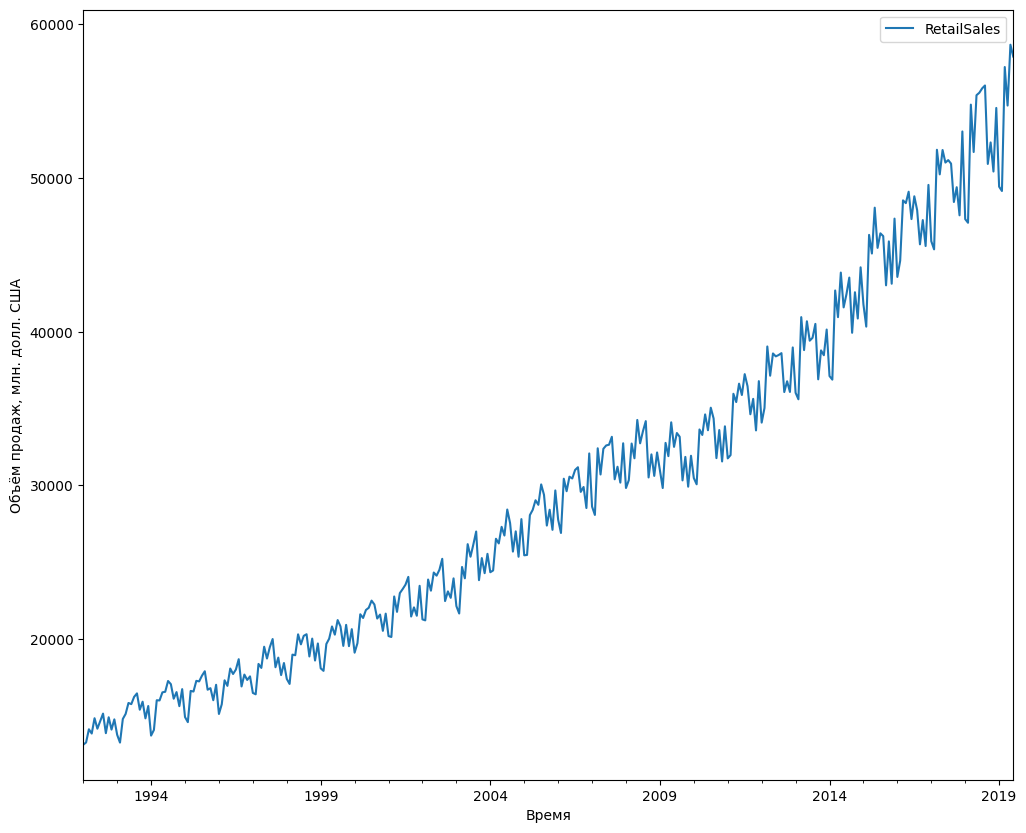

In [51]:
# Постройте график значений временного ряда (RetailSales)

df_retail.plot(x='Date', y='RetailSales', figsize=(12, 10))
plt.xlabel('Время')
plt.ylabel('Объём продаж, млн. долл. США')
plt.show()

In [52]:
# Создайте признаки lag 1m и lag 12m
# Подсказка: используйте shift

df_retail['lag 1m'] = df_retail['RetailSales'].shift(1)
df_retail['lag 12m'] = df_retail['RetailSales'].shift(12)

In [53]:
# Создайте признаки mean 3m и mean 12m
# Подсказка: используйте признак lag 1m и rolling

df_retail['mean 3m'] = df_retail['lag 1m'].rolling(window=3).mean()
df_retail['mean 12m'] = df_retail['lag 1m'].rolling(window=12).mean()

In [54]:
# Закодируйте метку времени (Date) как временные компоненты 

df_retail['day'] = df_retail['Date'].dt.day
df_retail['month'] = df_retail['Date'].dt.month
df_retail['year'] = df_retail['Date'].dt.year

In [55]:
# Закодируйте циклические переменные с помощью косинуса и синуса

df_retail['day_cos'] = np.cos(2 * np.pi * df_retail['day'] / 30)
df_retail['day_sin'] = np.sin(2 * np.pi * df_retail['day'] / 30)

df_retail['month_cos'] = np.cos(2 * np.pi * df_retail['month'] / 12)
df_retail['month_sin'] = np.sin(2 * np.pi * df_retail['month'] / 12)

In [56]:
# Датасет после создания признаков

df_retail

,Date,RetailSales,lag 1m,lag 12m,mean 3m,mean 12m,day,month,year,day_cos,day_sin,month_cos,month_sin
0,1992-01-01,13130,NaN,NaN,NaN,NaN,1,1,1992,0.978148,0.207912,8.660254e-01,5.000000e-01
1,1992-02-01,13276,13130.0,NaN,NaN,NaN,1,2,1992,0.978148,0.207912,5.000000e-01,8.660254e-01
2,1992-03-01,14135,13276.0,NaN,NaN,NaN,1,3,1992,0.978148,0.207912,6.123234e-17,1.000000e+00
3,1992-04-01,13858,14135.0,NaN,13513.666667,NaN,1,4,1992,0.978148,0.207912,-5.000000e-01,8.660254e-01
4,1992-05-01,14854,13858.0,NaN,13756.333333,NaN,1,5,1992,0.978148,0.207912,-8.660254e-01,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,2019-02-01,49162,49445.0,47095.0,51480.333333,52840.250000,1,2,2019,0.978148,0.207912,5.000000e-01,8.660254e-01
326,2019-03-01,57230,49162.0,54782.0,51058.000000,53012.500000,1,3,2019,0.978148,0.207912,6.123234e-17,1.000000e+00
327,2019-04-01,54723,57230.0,51700.0,51945.666667,53216.500000,1,4,2019,0.978148,0.207912,-5.000000e-01,8.660254e-01
328,2019-05-01,58681,54723.0,55395.0,53705.000000,53468.416667,1,5,2019,0.978148,0.207912,-8.660254e-01,5.000000e-01


In [57]:
# Удалите строки с пропущенными значениями
# Пропущенные значения появились после создания лаговых признаков и скользящих средних

df_retail = df_retail.dropna()

In [58]:
# Установите метку времени (Date) как индекс датасета df_retail

df_retail = df_retail.set_index('Date', drop=True)

In [59]:
# Выделите объясняемый фактор в отдельную переменную

X_retail = df_retail.drop(['RetailSales'], axis=1)
y_retail = df_retail['RetailSales']

In [60]:
# Разделите датасет на обучающую и тестовую выборки:
#   Обучающая выборка — все данные ранее 2016 года
#   Тестовая выборка  — все данные за 2016 год и позже

X_retail_train = X_retail[X_retail['year'] < 2016]
y_retail_train = y_retail[X_retail['year'] < 2016]

X_retail_test = X_retail[X_retail['year'] >= 2016]
y_retail_test = y_retail[X_retail['year'] >= 2016]

In [61]:
# На обучающей выборке обучите дерево решений tree_retail (DecisionTreeRegressor) с ограничениями:
#   min_samples_split=5
#   min_samples_leaf=2
# Не забудьте зафиксировать RANDOM_STATE

tree_retail = DecisionTreeRegressor(min_samples_split=5, min_samples_leaf=2, random_state=RANDOM_STATE)
tree_retail.fit(X_retail_train, y_retail_train)

DecisionTreeRegressor(min_samples_leaf=2, min_samples_split=5, random_state=42)

In [62]:
# Выведите metrics_report для дерева tree_retail на обучающей и тестовой выборках

print("Дерево на исходных значениях ряда (tree_retail):")
print("Обучающая выборка:")
metrics_report(y_retail_train, tree_retail.predict(X_retail_train))
print("\nТестовая выборка:")
metrics_report(y_retail_test, tree_retail.predict(X_retail_test))

Дерево на исходных значениях ряда (tree_retail):
Обучающая выборка:
R2 score: 0.9989
RMSE: 292.6740
MAPE: 0.0073

Тестовая выборка:
R2 score: -0.4995
RMSE: 4633.2400
MAPE: 0.0640


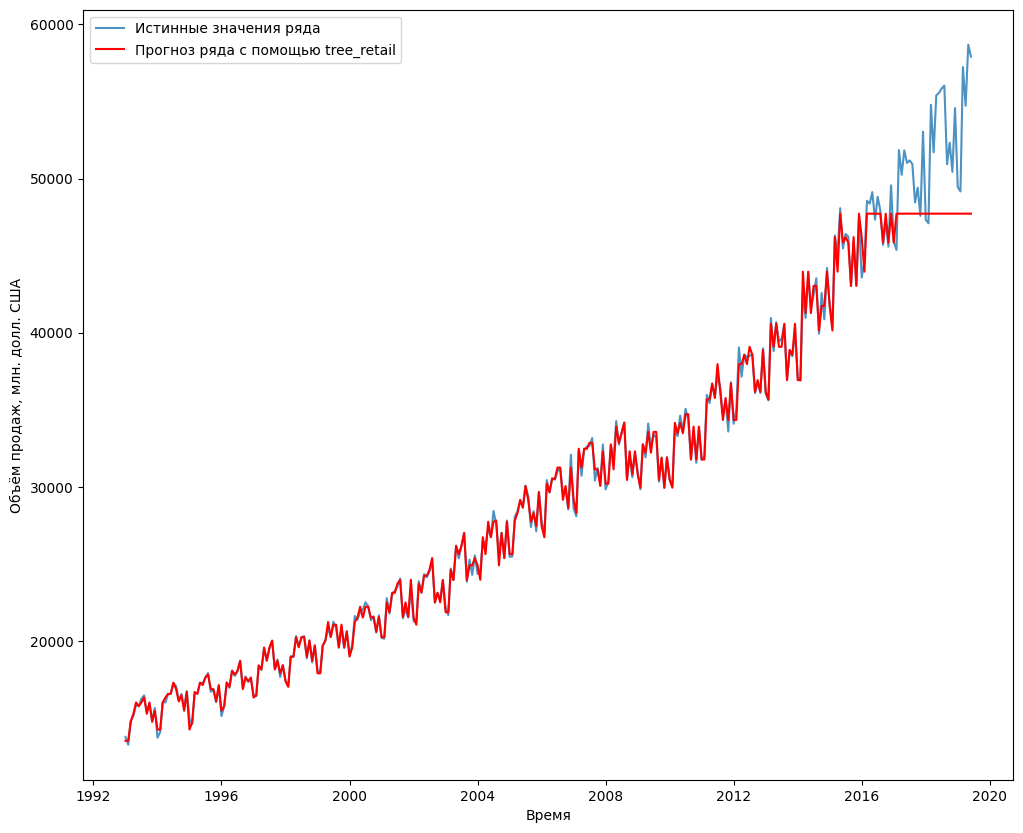

In [63]:
# Постройте график значений временного ряда (RetailSales)
# Добавьте на график прогноз значений ряда моделью tree_retail

plt.figure(figsize=(12, 10))
plt.plot(X_retail.index, y_retail, alpha=0.8, label='Истинные значения ряда')
plt.plot(X_retail.index, tree_retail.predict(X_retail), c='red', label='Прогноз ряда с помощью tree_retail')
plt.xlabel('Время')
plt.ylabel('Объём продаж, млн. долл. США')
plt.legend()
plt.show()

In [64]:
# Выделите новую объясняемую переменную y_retail_diff — абсолютные приросты значений временного ряда
# Подсказка: используйте shift

y_retail_diff = y_retail - y_retail.shift(1)
y_retail_diff = y_retail_diff[1:]
X_retail_diff = X_retail[1:]

In [65]:
# Разделите датасет на обучающую и тестовую выборки:
#   Обучающая выборка — все данные ранее 2016 года
#   Тестовая выборка  — все данные за 2016 год и позже

X_retail_diff_train = X_retail_diff[X_retail_diff['year'] < 2016]
y_retail_diff_train = y_retail_diff[X_retail_diff['year'] < 2016]

X_retail_diff_test = X_retail_diff[X_retail_diff['year'] >= 2016]
y_retail_diff_test = y_retail_diff[X_retail_diff['year'] >= 2016]

In [66]:
# На обучающей выборке обучите дерево tree_retail_diff (DecisionTreeRegressor) с ограничениями:
#   min_samples_split=5
#   min_samples_leaf=2
# В качестве объясняемой переменной используйте абсолютные приросты
# Не забудьте зафиксировать RANDOM_STATE

tree_retail_diff = DecisionTreeRegressor(min_samples_split=5, min_samples_leaf=2, random_state=RANDOM_STATE)
tree_retail_diff.fit(X_retail_diff_train, y_retail_diff_train)

DecisionTreeRegressor(min_samples_leaf=2, min_samples_split=5, random_state=42)

In [67]:
# Выведите metrics_report для дерева tree_retail_diff на обучающей и тестовой выборках (в абсолютных приростах)

print("Дерево на абсолютных приростах (tree_retail_diff):")
print("Обучающая выборка (приросты):")
metrics_report(y_retail_diff_train, tree_retail_diff.predict(X_retail_diff_train))
print("\nТестовая выборка (приросты):")
metrics_report(y_retail_diff_test, tree_retail_diff.predict(X_retail_diff_test))

Дерево на абсолютных приростах (tree_retail_diff):
Обучающая выборка (приросты):
R2 score: 0.9729
RMSE: 279.9254
MAPE: 0.5546

Тестовая выборка (приросты):
R2 score: 0.8147
RMSE: 1394.2334
MAPE: 1.5168


Проанализируем каждое утверждение на основе данных:

**Данные:**
- tree_retail (исходные значения):
  - Обучающая: R²=0.9989, RMSE=292.67
  - Тестовая: R²=-0.4995, RMSE=4633.24 (катастрофическое падение качества)
- tree_retail_diff (абсолютные приросты):
  - Обучающая: R²=0.9729, RMSE=279.93
  - Тестовая: R²=0.8147, RMSE=1394.23 (хорошее качество)

**Анализ утверждений:**

1. **"Переход к предсказанию абсолютных приростов (разностей) вместо исходных значений временного ряда улучшает качество модели, так как деревья решений плохо экстраполируют тренд."**
   - **ВЕРНО**. Данные подтверждают: tree_retail_diff показывает хорошие результаты на тесте (R²=0.8147), в то время как tree_retail на тесте проваливается (R²=-0.4995). Это классическая проблема деревьев с трендовыми рядами.

2. **"Деревья решений хорошо адаптируются к структурным изменениям во временных рядах (например, к изменениям в тренде или дисперсии ряда) без переобучения модели."**
   - **НЕВЕРНО**. Данные показывают обратное: tree_retail сильно переобучился (R²=0.9989 на обучении и -0.4995 на тесте) и не смог адаптироваться к изменениям.

3. **"Значение R² для модели tree_retail на тестовой выборке приняло отрицательное значение, поскольку модель недообучена и обладает недостаточной глубиной для данной задачи."**
   - **НЕВЕРНО**. R²=0.9989 на обучении указывает на сильное переобучение, а не на недообучение. Отрицательный R² на тесте - следствие переобучения и неспособности экстраполировать.

4. **"Значение R² для модели tree_retail на тестовой выборке принял отрицательное значение, так как деревья решений не могут предсказывать значения за пределами диапазона значений, характерного для обучающей выборки."**
   - **ВЕРНО**. Это фундаментальное ограничение деревьев решений: они не экстраполируют за пределы значений, виденных на обучении. При наличии тренда тестовые значения выходят за этот диапазон.

5. **"Увеличение параметра min_samples_leaf (минимальное количество объектов в листе) приведёт к построению более простых деревьев."**
   - **ВЕРНО**. Увеличение min_samples_leaf ограничивает возможность дальнейшего разделения узлов, что приводит к более простым деревьям с меньшей глубиной.

**Верные утверждения: 1, 4, 5**

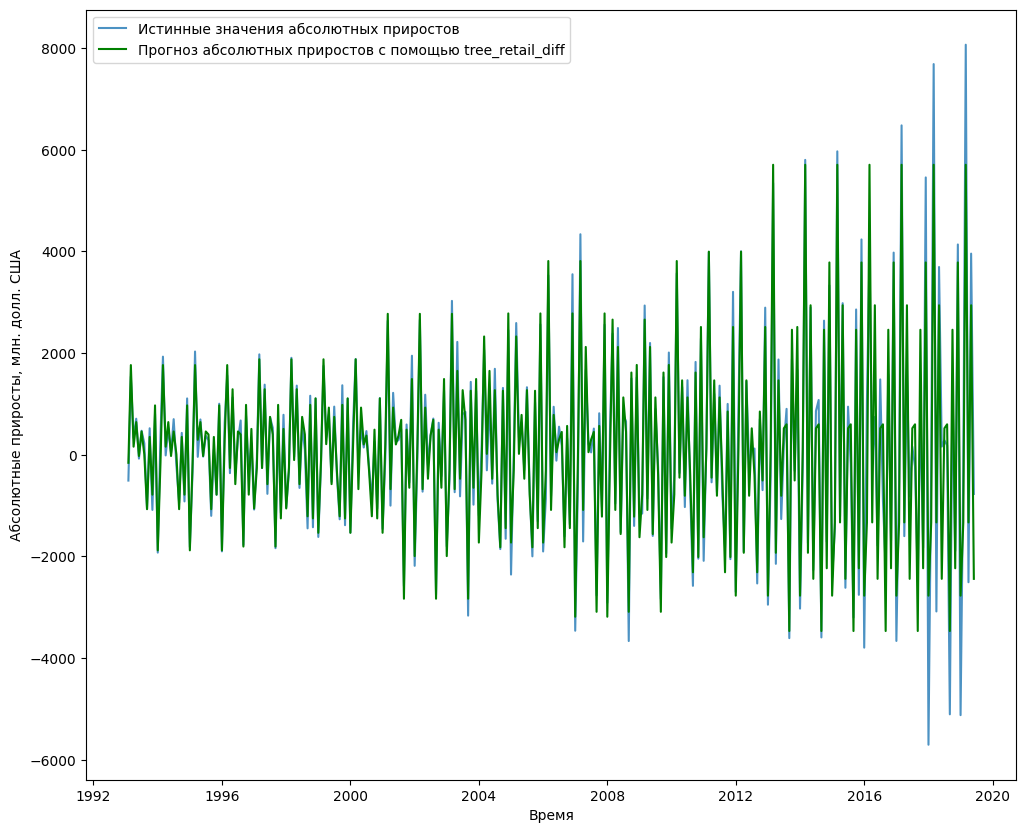

In [68]:
# Постройте график значений абсолютных приростов
# Добавьте на график прогноз абсолютных приростов моделью tree_retail_diff

plt.figure(figsize=(12, 10))
plt.plot(X_retail_diff.index, y_retail_diff, alpha=0.8, label='Истинные значения абсолютных приростов')
plt.plot(X_retail_diff.index, tree_retail_diff.predict(X_retail_diff), c='green', label='Прогноз абсолютных приростов с помощью tree_retail_diff')
plt.xlabel('Время')
plt.ylabel('Абсолютные приросты, млн. долл. США')
plt.legend()
plt.show()

In [69]:
# На тестовой выборке преобразуйте предсказанные моделью tree_retail_diff абсолютные приросты в исходные значения временного ряда 

y_test_pred_tree_retail_diff = y_retail_train.iloc[-1] + tree_retail_diff.predict(X_retail_diff_test).cumsum()

In [70]:
# Выведите metrics_report на тестовой выборке после обратного перехода от прогноза приростов к исходным значениям

metrics_report(y_retail_test, y_test_pred_tree_retail_diff)

R2 score: 0.9077
RMSE: 1149.5225
MAPE: 0.0181


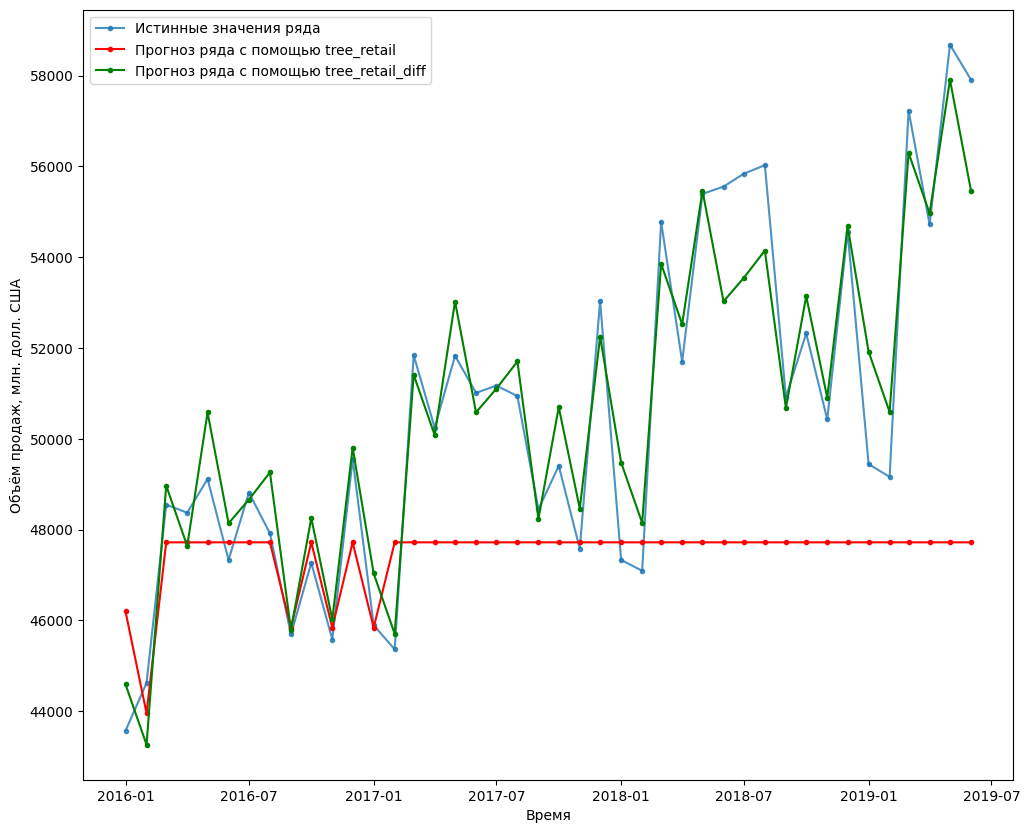

In [71]:
# Постройте график значений временного ряда (RetailSales) на тестовой выборке
# Добавьте на график прогноз значений ряда с помощью моделей tree_retail и tree_retail_diff

plt.figure(figsize=(12, 10))
plt.plot(X_retail_test.index, y_retail_test, marker='.', alpha=0.8, label='Истинные значения ряда')
plt.plot(X_retail_test.index, tree_retail.predict(X_retail_test), marker='.', c='red', label='Прогноз ряда с помощью tree_retail')
plt.plot(X_retail_test.index, y_test_pred_tree_retail_diff, marker='.', c='green', label='Прогноз ряда с помощью tree_retail_diff')
plt.xlabel('Время')
plt.ylabel('Объём продаж, млн. долл. США')
plt.legend()
plt.show()